In [3]:
#add formatted_title and reads_url column in csv file
import pandas as pd
import json
from urllib.parse import quote
import urllib.request
import numpy as np

df = pd.read_csv('data/sheet1_wikipedia.csv')
df = df.fillna('')
titles_list = df['Page title'].tolist()
formatted_titles_list = []
reads_url_list = []
for title in titles_list:
    if title == '':
        formatted_title = ''
        reads_url = ''
        formatted_titles_list.append(formatted_title)
        reads_url_list.append(reads_url)
    else:   
        formatted_title = quote(title.replace(' ', '_'))
        reads_url = f'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/user/{formatted_title}/monthly/20150701/20230731'
        formatted_titles_list.append(formatted_title)
        reads_url_list.append(reads_url)
df['formatted_title'] = formatted_titles_list
df['reads_url'] = reads_url_list
df.to_csv('data/sheet1_output.csv', index=False)

In [ ]:
#scrape the reads data and write everything into a csv file
list_of_dicts = []
df = pd.read_csv('data/sheet1_output.csv')
df = df.fillna('')
reads_url_list = df['reads_url'].tolist()
for reads_url in reads_url_list:
        if reads_url == '':
                list_of_dicts.append([])
        else:
                with urllib.request.urlopen(reads_url) as url:
                        data = url.read().decode('utf-8')
                        items_dict = json.loads(data)
                        
                        desired_keys = ['article', 'timestamp', 'views']
                        items_list = items_dict.get('items', [])
                        selected_data = []
                        for item in items_list:
                                selected_item = {key: item[key] for key in desired_keys if key in item}
                                selected_data.append(selected_item)
                        list_of_dicts.append(selected_data)
formatted_list = []
for list in list_of_dicts:
        if len(list) == 0: # if the list is empty (when the algo has no wikipedia page)
                formatted_list.append({})
        else:
                formatted_dict = {}
                for dict in list:
                        formatted_dict['formatted_title'] = dict['article']
                        formatted_dict[dict['timestamp']] = dict['views']
                formatted_list.append(formatted_dict)

df_output = pd.DataFrame(formatted_list)
df_output = df_output.drop('formatted_title', axis=1)
df_output['average_monthly_reads'] = df_output.mean(axis=1)
df_output.to_csv('data/views.csv', index=False)
merged_df = pd.merge(df, df_output, left_index=True, right_index=True)
merged_df.to_csv('data/sheet1_output_views.csv', index=False)

max_reads70000
num_bins14
bins[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
optimal_counts[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
non_optimal_counts[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
optimal_counts[130, 39, 23, 21, 9, 5, 5, 3, 2, 4, 2, 0, 3, 1]
non_optimal_counts[199, 74, 36, 38, 5, 6, 2, 2, 3, 8, 1, 0, 2, 0]
optimal_percent[52.63157894736842, 15.789473684210526, 9.31174089068826, 8.502024291497975, 3.643724696356275, 2.0242914979757085, 2.0242914979757085, 1.214574898785425, 0.8097165991902834, 1.6194331983805668, 0.8097165991902834, 0.0, 1.214574898785425, 0.4048582995951417]
non_optimal_percent[52.92553191489362, 19.680851063829788, 9.574468085106384, 10.106382978723403, 1.3297872340425532, 1.5957446808510638, 0.5319148936170213, 0.5319148936170213, 0.7978723404255319, 2.127659574468085, 0.26595744680851063, 0.0, 0.5319148936170213, 0.0]


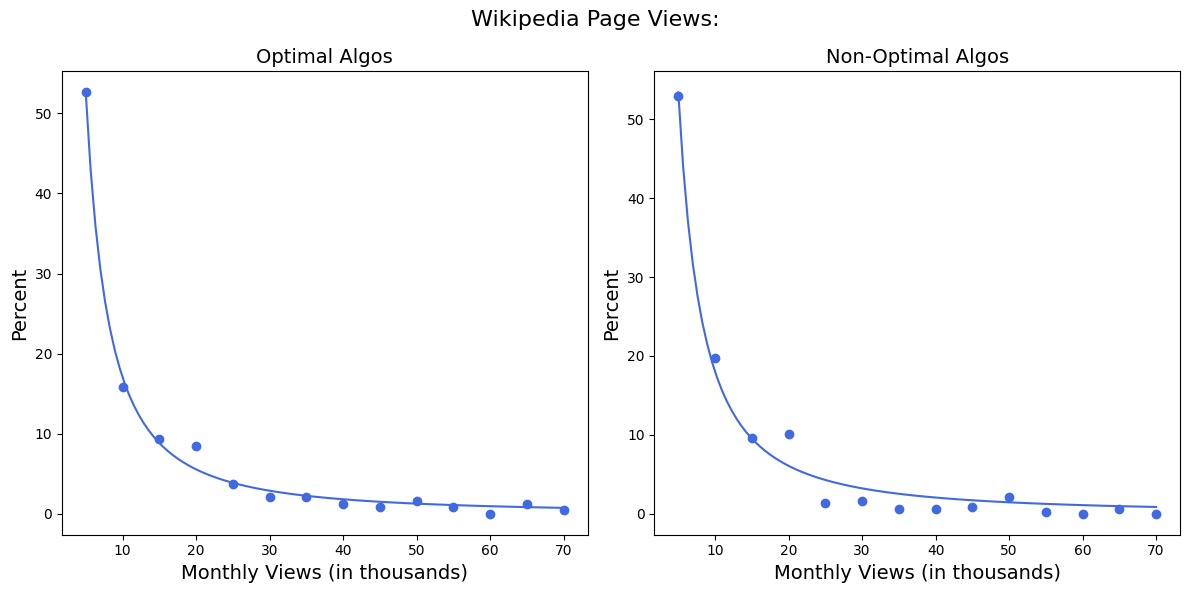

In [98]:
import math
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import powerlaw

#merge the reads csv file with the original
df = pd.read_csv('data/sheet1_output_views.csv')
df = df.fillna('')

dict = df.to_dict(orient='records')

min_time_complexities = {}

# Iterate through the list of dictionaries and find min time complexity class for each family
for entry in dict:
    family_name = entry['Family Name']
    time_complexity_class = entry['Time Complexity Class']
    
    if family_name not in min_time_complexities:
        min_time_complexities[family_name] = time_complexity_class
    else:
        min_time_complexities[family_name] = min(min_time_complexities[family_name], time_complexity_class)

# Iterate through the list of dictionaries and add the min_time_complexity_class to each entry
for entry in dict:
    family_name = entry['Family Name']
    entry['min_time_complexity_class'] = min_time_complexities[family_name]
    if entry['min_time_complexity_class'] == entry['Time Complexity Class']:
        entry['is_optimal'] = True
    else:
        entry['is_optimal'] = False

df = pd.DataFrame(dict)
df.to_csv('data/merged.csv', index=False)

reads_all = []
reads_optimal = []
reads_not_optimal = []
total_optimal = 0
wiki_optimal = 0
total_algos = 0
for algo in dict:
    total_algos += 1
    if algo['2015070100'] != '':
        reads_all.append(float(algo['2015070100'] + algo['2015080100'] + algo['2015090100'] + algo['2015100100'] + algo['2015110100'] + algo['2015120100'] + algo['2016010100'] + algo['2016020100'] + algo['2016030100'] + algo['2016040100'] + algo['2016050100'] + algo['2016060100'] + algo['2016070100'] + algo['2016080100'] + algo['2016090100'] + algo['2016100100'] + algo['2016110100'] + algo['2016120100'] + algo['2017010100'] + algo['2017020100'] + algo['2017030100'] + algo['2017040100'] + algo['2017050100'] + algo['2017060100'] + algo['2017070100'] + algo['2017080100'] + algo['2017090100'] + algo['2017100100'] + algo['2017110100'] + algo['2017120100'] + algo['2018010100'] + algo['2018020100'] + algo['2018030100'] + algo['2018040100'] + algo['2018050100'] + algo['2018060100'] + algo['2018070100'] + algo['2018080100'] + algo['2018090100'] + algo['2018100100'] + algo['2018110100'] + algo['2018120100'] + algo['2019010100'] + algo['2019020100'] + algo['2019030100'] + algo['2019040100'] + algo['2019050100'] + algo['2019060100'] + algo['2019070100'] + algo['2019080100'] + algo['2019090100'] + algo['2019100100'] + algo['2019110100'] + algo['2019120100'] + algo['2020010100'] + algo['2020020100'] + algo['2020030100'] + algo['2020040100'] + algo['2020050100'] + algo['2020060100'] + algo['2020070100'] + algo['2020080100'] + algo['2020090100'] + algo['2020100100'] + algo['2020110100'] + algo['2020120100'] + algo['2021010100'] + algo['2021020100'] + algo['2021030100'] + algo['2021040100'] + algo['2021050100'] + algo['2021060100'] + algo['2021070100'] + algo['2021080100'] + algo['2021090100'] + algo['2021100100'] + algo['2021110100'] + algo['2021120100'] + algo['2022010100'] + algo['2022020100'] + algo['2022030100'] + algo['2022040100'] + algo['2022050100'] + algo['2022060100'] + algo['2022070100'] + algo['2022080100'] + algo['2022090100'] + algo['2022100100'] + algo['2022110100'] + algo['2022120100'] + algo['2023010100'] + algo['2023020100'] + algo['2023030100'] + algo['2023040100'] + algo['2023050100'] + algo['2023060100'] + algo['2023070100'])/97)
        if algo['is_optimal'] == True:
            wiki_optimal += 1
            reads_optimal.append(float(algo['2015070100'] + algo['2015080100'] + algo['2015090100'] + algo['2015100100'] + algo['2015110100'] + algo['2015120100'] + algo['2016010100'] + algo['2016020100'] + algo['2016030100'] + algo['2016040100'] + algo['2016050100'] + algo['2016060100'] + algo['2016070100'] + algo['2016080100'] + algo['2016090100'] + algo['2016100100'] + algo['2016110100'] + algo['2016120100'] + algo['2017010100'] + algo['2017020100'] + algo['2017030100'] + algo['2017040100'] + algo['2017050100'] + algo['2017060100'] + algo['2017070100'] + algo['2017080100'] + algo['2017090100'] + algo['2017100100'] + algo['2017110100'] + algo['2017120100'] + algo['2018010100'] + algo['2018020100'] + algo['2018030100'] + algo['2018040100'] + algo['2018050100'] + algo['2018060100'] + algo['2018070100'] + algo['2018080100'] + algo['2018090100'] + algo['2018100100'] + algo['2018110100'] + algo['2018120100'] + algo['2019010100'] + algo['2019020100'] + algo['2019030100'] + algo['2019040100'] + algo['2019050100'] + algo['2019060100'] + algo['2019070100'] + algo['2019080100'] + algo['2019090100'] + algo['2019100100'] + algo['2019110100'] + algo['2019120100'] + algo['2020010100'] + algo['2020020100'] + algo['2020030100'] + algo['2020040100'] + algo['2020050100'] + algo['2020060100'] + algo['2020070100'] + algo['2020080100'] + algo['2020090100'] + algo['2020100100'] + algo['2020110100'] + algo['2020120100'] + algo['2021010100'] + algo['2021020100'] + algo['2021030100'] + algo['2021040100'] + algo['2021050100'] + algo['2021060100'] + algo['2021070100'] + algo['2021080100'] + algo['2021090100'] + algo['2021100100'] + algo['2021110100'] + algo['2021120100'] + algo['2022010100'] + algo['2022020100'] + algo['2022030100'] + algo['2022040100'] + algo['2022050100'] + algo['2022060100'] + algo['2022070100'] + algo['2022080100'] + algo['2022090100'] + algo['2022100100'] + algo['2022110100'] + algo['2022120100'] + algo['2023010100'] + algo['2023020100'] + algo['2023030100'] + algo['2023040100'] + algo['2023050100'] + algo['2023060100'] + algo['2023070100'])/97)
        elif algo['is_optimal'] == False:
            reads_not_optimal.append(float(algo['2015070100'] + algo['2015080100'] + algo['2015090100'] + algo['2015100100'] + algo['2015110100'] + algo['2015120100'] + algo['2016010100'] + algo['2016020100'] + algo['2016030100'] + algo['2016040100'] + algo['2016050100'] + algo['2016060100'] + algo['2016070100'] + algo['2016080100'] + algo['2016090100'] + algo['2016100100'] + algo['2016110100'] + algo['2016120100'] + algo['2017010100'] + algo['2017020100'] + algo['2017030100'] + algo['2017040100'] + algo['2017050100'] + algo['2017060100'] + algo['2017070100'] + algo['2017080100'] + algo['2017090100'] + algo['2017100100'] + algo['2017110100'] + algo['2017120100'] + algo['2018010100'] + algo['2018020100'] + algo['2018030100'] + algo['2018040100'] + algo['2018050100'] + algo['2018060100'] + algo['2018070100'] + algo['2018080100'] + algo['2018090100'] + algo['2018100100'] + algo['2018110100'] + algo['2018120100'] + algo['2019010100'] + algo['2019020100'] + algo['2019030100'] + algo['2019040100'] + algo['2019050100'] + algo['2019060100'] + algo['2019070100'] + algo['2019080100'] + algo['2019090100'] + algo['2019100100'] + algo['2019110100'] + algo['2019120100'] + algo['2020010100'] + algo['2020020100'] + algo['2020030100'] + algo['2020040100'] + algo['2020050100'] + algo['2020060100'] + algo['2020070100'] + algo['2020080100'] + algo['2020090100'] + algo['2020100100'] + algo['2020110100'] + algo['2020120100'] + algo['2021010100'] + algo['2021020100'] + algo['2021030100'] + algo['2021040100'] + algo['2021050100'] + algo['2021060100'] + algo['2021070100'] + algo['2021080100'] + algo['2021090100'] + algo['2021100100'] + algo['2021110100'] + algo['2021120100'] + algo['2022010100'] + algo['2022020100'] + algo['2022030100'] + algo['2022040100'] + algo['2022050100'] + algo['2022060100'] + algo['2022070100'] + algo['2022080100'] + algo['2022090100'] + algo['2022100100'] + algo['2022110100'] + algo['2022120100'] + algo['2023010100'] + algo['2023020100'] + algo['2023030100'] + algo['2023040100'] + algo['2023050100'] + algo['2023060100'] + algo['2023070100'])/97)
    if algo['is_optimal'] == True:
            total_optimal += 1

# get max reads value
max_reads = math.ceil(max(max(reads_optimal), max(reads_not_optimal)) / 5000) * 5000
print("max_reads" + str(max_reads))
num_bins = int(max_reads/5000)
print("num_bins" + str(num_bins))
bins = []
for i in range(num_bins):
    bins.append((i*5)+5)

print("bins" + str(bins))

optimal_counts = []
non_optimal_counts = []
for i in range(num_bins):
    optimal_counts.append(0)
    non_optimal_counts.append(0)
print("optimal_counts" + str(optimal_counts))
print("non_optimal_counts" + str(non_optimal_counts))

for reads in reads_optimal:
    if reads < (bins[0]*1000):
        optimal_counts[0]+=1
    elif reads >= (bins[0]*1000) and (reads < (bins[1]*1000)):
        optimal_counts[1]+=1
    elif reads >= (bins[1]*1000) and (reads < (bins[2]*1000)):
        optimal_counts[2]+=1
    elif reads >= (bins[2]*1000) and (reads < (bins[3]*1000)):
        optimal_counts[3]+=1
    elif reads >= (bins[3]*1000) and (reads < (bins[4]*1000)):
        optimal_counts[4]+=1
    elif reads >= (bins[4]*1000) and (reads < (bins[5]*1000)):
        optimal_counts[5]+=1
    elif reads >= (bins[5]*1000) and (reads < (bins[6]*1000)):
        optimal_counts[6]+=1
    elif reads >= (bins[6]*1000) and (reads < (bins[7]*1000)):
        optimal_counts[7]+=1
    elif reads >= (bins[7]*1000) and (reads < (bins[8]*1000)):
        optimal_counts[8]+=1
    elif reads >= (bins[8]*1000) and (reads < (bins[9]*1000)):
        optimal_counts[9]+=1
    elif reads >= (bins[9]*1000) and (reads < (bins[10]*1000)):
        optimal_counts[10]+=1
    elif reads >= (bins[10]*1000) and (reads < (bins[11]*1000)):
        optimal_counts[11]+=1
    elif reads >= (bins[11]*1000) and (reads < (bins[12]*1000)):
        optimal_counts[12]+=1
    elif reads >= (bins[12]*1000) and (reads < (bins[13]*1000)):
        optimal_counts[13]+=1


for reads in reads_not_optimal:
    if reads < (bins[0]*1000):
        non_optimal_counts[0]+=1
    elif reads >= (bins[0]*1000) and (reads < (bins[1]*1000)):
        non_optimal_counts[1]+=1
    elif reads >= (bins[1]*1000) and (reads < (bins[2]*1000)):
        non_optimal_counts[2]+=1
    elif reads >= (bins[2]*1000) and (reads < (bins[3]*1000)):
        non_optimal_counts[3]+=1
    elif reads >= (bins[3]*1000) and (reads < (bins[4]*1000)):
        non_optimal_counts[4]+=1
    elif reads >= (bins[4]*1000) and (reads < (bins[5]*1000)):
        non_optimal_counts[5]+=1
    elif reads >= (bins[5]*1000) and (reads < (bins[6]*1000)):
        non_optimal_counts[6]+=1
    elif reads >= (bins[6]*1000) and (reads < (bins[7]*1000)):
        non_optimal_counts[7]+=1
    elif reads >= (bins[7]*1000) and (reads < (bins[8]*1000)):
        non_optimal_counts[8]+=1
    elif reads >= (bins[8]*1000) and (reads < (bins[9]*1000)):
        non_optimal_counts[9]+=1
    elif reads >= (bins[9]*1000) and (reads < (bins[10]*1000)):
        non_optimal_counts[10]+=1
    elif reads >= (bins[10]*1000) and (reads < (bins[11]*1000)):
        non_optimal_counts[11]+=1
    elif reads >= (bins[11]*1000) and (reads < (bins[12]*1000)):
        non_optimal_counts[12]+=1
    elif reads >= (bins[12]*1000) and (reads < (bins[13]*1000)):
        non_optimal_counts[13]+=1
print("optimal_counts" + str(optimal_counts))
print("non_optimal_counts" + str(non_optimal_counts))

optimal_percent = []
non_optimal_percent = []
for i in range(num_bins):
    optimal_percent.append(optimal_counts[i]/len(reads_optimal)*100)
    non_optimal_percent.append(non_optimal_counts[i]/len(reads_not_optimal)*100)
print("optimal_percent" + str(optimal_percent))
print("non_optimal_percent" + str(non_optimal_percent))

x = np.array(bins)
y1 = np.array(optimal_percent)
y2 = np.array(non_optimal_percent)

# Fit power law curve
def power_law(x, a, b):
    return a * np.power(x, b)

popt1, _ = curve_fit(power_law, x, optimal_percent)
popt2, _ = curve_fit(power_law, x, non_optimal_percent)


# Plot the data points
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

x_smooth_fit = np.linspace(min(x), max(x), 100)
axes[0].plot(x_smooth_fit, power_law(x_smooth_fit, *popt1), '-', label='Power Law Fit', color="royalblue")
axes[1].plot(x_smooth_fit, power_law(x_smooth_fit, *popt2), '-', label='Power Law Fit', color="royalblue")


axes[0].scatter(x, y1, color='royalblue', label='Data')
axes[1].scatter(x, y2, color='royalblue', label='Data')

axes[0].set_title('Optimal Algos', fontsize=14)
axes[0].set_xlabel('Monthly Views (in thousands)', fontsize=14)
axes[0].set_ylabel('Percent', fontsize=14)

axes[1].set_title('Non-Optimal Algos', fontsize=14)
axes[1].set_xlabel('Monthly Views (in thousands)', fontsize=14)
axes[1].set_ylabel('Percent', fontsize=14)

fig.suptitle('Wikipedia Page Views:', fontsize=16)

plt.tight_layout()
plt.savefig('figures/fig1.pdf')
plt.savefig('figures/fig1.png')
plt.show()

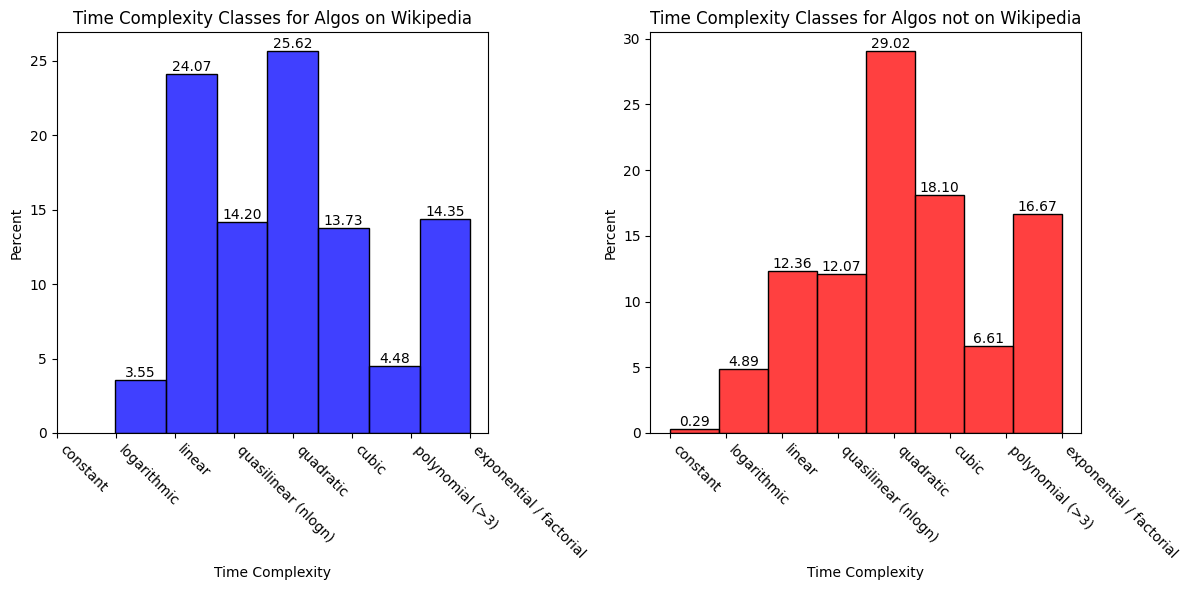

KS Statistic: 0.1165921668795232
P-value: 0.003822361908085234
The two datasets are significantly different (reject the null hypothesis)
Earth Mover's Distance: 0.3785991639075138
Chi-Squared Statistic: 20.738353593377475
P-value: 0.004177328387023678
The two datasets are significantly different (reject the null hypothesis)


In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance
from scipy.stats import chi2_contingency

df = pd.read_csv('data/merged.csv')
merged_dict = df.to_dict(orient='records')

wiki_complexity_classes = []
non_wiki_complexity_classes = []
for algo in merged_dict:
    if algo['Time Complexity Class'] != '#VALUE!':
        if algo['One of them'] == 1:
            wiki_complexity_classes.append(float(algo['Time Complexity Class']))
        else:
            non_wiki_complexity_classes.append(float(algo['Time Complexity Class']))

bin_edges = [1, 2, 3, 4, 5, 6, 7, 8]
bin_labels = ['constant', 'logarithmic', 'linear', 'quasilinear (nlogn)', 'quadratic', 'cubic', 'polynomial (>3)', 'exponential / factorial']

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Plot the histogram for wiki_complexity_classes
ax1 = sns.histplot(wiki_complexity_classes, kde=False, bins=7, stat='percent', color='blue', edgecolor='black', ax=axes[0])
ax1.set_title('Time Complexity Classes for Algos on Wikipedia')
ax1.set_xlabel('Time Complexity')
ax1.set_ylabel('Percent')
ax1.set_xticks(bin_edges)
ax1.set_xticklabels(bin_labels, rotation=-45, ha='left')

# Add heights (percentages) on top of bars in the first subplot
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

# Plot the histogram for non_wiki_complexity_classes
ax2 = sns.histplot(non_wiki_complexity_classes, kde=False, bins=8, stat='percent', color='red', edgecolor='black', ax=axes[1])
ax2.set_title('Time Complexity Classes for Algos not on Wikipedia')
ax2.set_xlabel('Time Complexity')
ax2.set_ylabel('Percent')
ax2.set_xticks(bin_edges)
ax2.set_xticklabels(bin_labels, rotation=-45, ha='left')

# Add heights (percentages) on top of bars in the second subplot
for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Perform K-S test:
ks_statistic, p_value = ks_2samp(wiki_complexity_classes, non_wiki_complexity_classes)

print("KS Statistic:", ks_statistic)
print("P-value:", p_value)

alpha = 0.05  # Significance level
if p_value < alpha:
    print("The two datasets are significantly different (reject the null hypothesis)")
else:
    print("There is no significant difference between the two datasets (fail to reject the null hypothesis)")

# Compute the Earth Mover's Distance (EMD)
emd_distance = wasserstein_distance(wiki_complexity_classes, non_wiki_complexity_classes)

print("Earth Mover's Distance:", emd_distance)

# Chi-squared test:
# Create a contingency table
observed_frequencies = np.array([[
    len([x for x in wiki_complexity_classes if x == class_label]),
    len([x for x in non_wiki_complexity_classes if x == class_label])
] for class_label in range(1, 9)])

# Perform the chi-squared test
chi2, p, _, _ = chi2_contingency(observed_frequencies)

print("Chi-Squared Statistic:", chi2)
print("P-value:", p)

# Interpret the result
alpha = 0.05  # Significance level
if p < alpha:
    print("The two datasets are significantly different (reject the null hypothesis)")
else:
    print("There is no significant difference between the two datasets (fail to reject the null hypothesis)")


One of them                 0         1
Time Complexity Bin                    
1                    0.002874  0.001543
2                    0.051724  0.033951
3                    0.123563  0.242284
4                    0.132184  0.143519
5                    0.310345  0.271605
6                    0.152299  0.123457
7                    0.060345  0.041667
8                    0.166667  0.141975


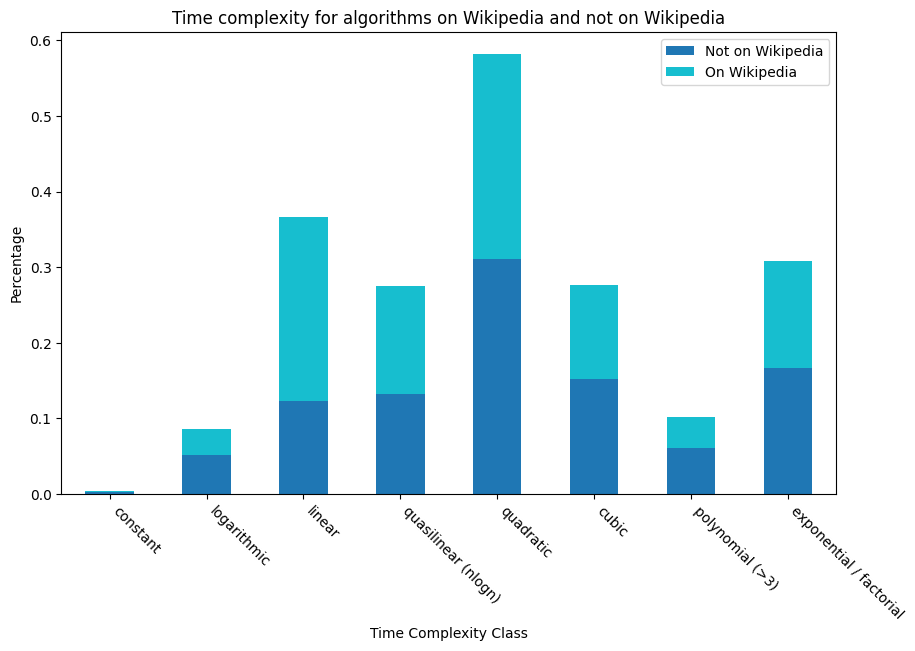

In [100]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/merged.csv')
df = df[['One of them','Time Complexity Class']]
df = df.replace('#VALUE!', pd.NA).dropna()
df['Time Complexity Class'] = df['Time Complexity Class'].astype(float)
merged_dict = df.to_dict(orient='records')
for algo in merged_dict:
    if algo['Time Complexity Class'] < 2:
        algo['Time Complexity Bin'] = 1
    elif algo['Time Complexity Class'] < 3:
        algo['Time Complexity Bin'] = 2
    elif algo['Time Complexity Class'] < 4:
        algo['Time Complexity Bin'] = 3
    elif algo['Time Complexity Class'] < 5:
        algo['Time Complexity Bin'] = 4
    elif algo['Time Complexity Class'] < 6:
        algo['Time Complexity Bin'] = 5
    elif algo['Time Complexity Class'] < 7:
        algo['Time Complexity Bin'] = 6
    elif algo['Time Complexity Class'] < 8:
        algo['Time Complexity Bin'] = 7
    elif algo['Time Complexity Class'] < 9:
        algo['Time Complexity Bin'] = 8
df = pd.DataFrame(merged_dict)



grouped = df.groupby(['Time Complexity Bin','One of them']).size().unstack(fill_value=0)
dict = grouped.to_dict()

total_not_in_wiki = dict[0][1] + dict[0][2] + dict[0][3] + dict[0][4] + dict[0][5] + dict[0][6] + dict[0][7] + dict[0][8]
total_in_wiki = dict[1][1] + dict[1][2] + dict[1][3] + dict[1][4] + dict[1][5] + dict[1][6] + dict[1][7] + dict[1][8]

grouped[0] = grouped[0] / total_not_in_wiki
grouped[1] = grouped[1] / total_in_wiki
print(grouped)


# Create a stacked bar plot
ax = grouped.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')

plt.xlabel('Time Complexity Class')
plt.ylabel('Percentage')
plt.title('Time complexity for algorithms on Wikipedia and not on Wikipedia')
plt.legend(title='One of them')

bin_labels = ['constant', 'logarithmic', 'linear', 'quasilinear (nlogn)', 'quadratic', 'cubic', 'polynomial (>3)', 'exponential / factorial']

ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=-45, ha = 'left')

custom_legend_labels = {0: 'Not on Wikipedia', 1: 'On Wikipedia'}
legend = plt.legend(custom_legend_labels.values())

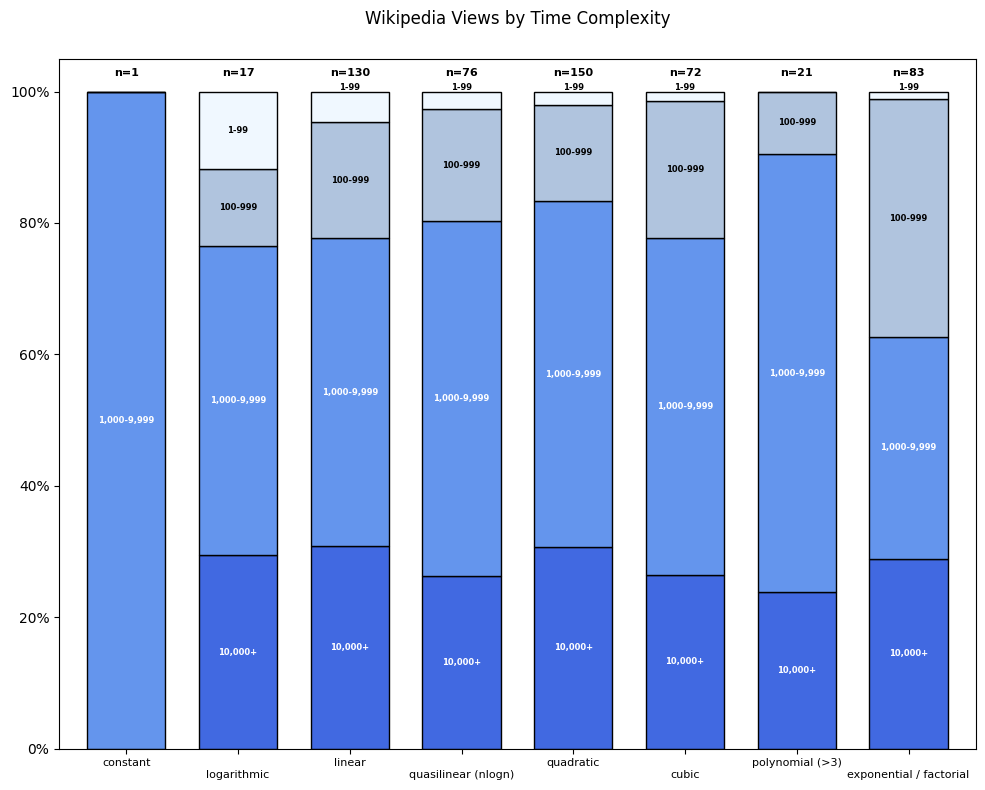

In [101]:
#Option 2
#divide up bars by views

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv('data/merged.csv')
df = df[['average_monthly_reads','Time Complexity Class']]
df['Time Complexity Class'] = df['Time Complexity Class'].replace('#VALUE!', pd.NA)
df['average_monthly_reads'] = df['average_monthly_reads'].fillna(0)
df = df.dropna()

num_bins = 4
df = df.astype(float)
merged_dict = df.to_dict(orient='records')
for algo in merged_dict:
    if algo['Time Complexity Class'] < 2:
        algo['Time Complexity Bin'] = 1
    elif algo['Time Complexity Class'] < 3:
        algo['Time Complexity Bin'] = 2
    elif algo['Time Complexity Class'] < 4:
        algo['Time Complexity Bin'] = 3
    elif algo['Time Complexity Class'] < 5:
        algo['Time Complexity Bin'] = 4
    elif algo['Time Complexity Class'] < 6:
        algo['Time Complexity Bin'] = 5
    elif algo['Time Complexity Class'] < 7:
        algo['Time Complexity Bin'] = 6
    elif algo['Time Complexity Class'] < 8:
        algo['Time Complexity Bin'] = 7
    elif algo['Time Complexity Class'] < 9:
        algo['Time Complexity Bin'] = 8
    
    if (algo['average_monthly_reads'] == 0):
        merged_dict.remove(algo)
    elif (algo['average_monthly_reads'] <100):
        algo['reads_bin'] = 3
    elif algo['average_monthly_reads'] <1000:
        algo['reads_bin'] = 2
    elif algo['average_monthly_reads'] <10000:
        algo['reads_bin'] = 1
    elif algo['average_monthly_reads'] >=10000:
        algo['reads_bin'] = 0
    else:
        merged_dict.remove(algo)

df = pd.DataFrame(merged_dict)

crosstb_prop = pd.crosstab(df["Time Complexity Bin"], df['reads_bin'], normalize="index")
crosstb_prop *= 100
crosstb = pd.crosstab(df["Time Complexity Bin"], df['reads_bin'])


crosstb_prop.plot(kind='bar', stacked=True, color=['royalblue', 'cornflowerblue', 'lightsteelblue', 'aliceblue'], edgecolor='black', figsize=(10, 8), width=0.7)

#title and axes
plt.xlabel("Time Complexity")
plt.title('Wikipedia Views by Time Complexity', pad=25)

bin_labels = ['constant', '\nlogarithmic', 'linear', '\nquasilinear (nlogn)', 'quadratic', '\ncubic', 'polynomial (>3)', '\nexponential / factorial']

# # Set the x-ticks and x-tick labels
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_xlabel('')

ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=8)
ax.get_legend().remove()

for n, x in enumerate([*crosstb_prop.index.values]):
    total = 0
    for (proportion, count, y_loc) in zip(crosstb_prop.loc[x],
                                          crosstb.loc[x],
                                          crosstb_prop.loc[x].cumsum()):
        total += count
    plt.text(x=n,
                 y=(y_loc) + 2,
                 s="n=" + str(total), 
                 color="black",
                 ha='center',
                 va='bottom',
                 fontsize=8,
                 fontweight="bold")


y = 0
for n, x in enumerate([*crosstb_prop.index.values]):
    total = 0
    for (proportion, count, y_loc) in zip(crosstb_prop.loc[x],
                                          crosstb.loc[x],
                                          crosstb_prop.loc[x].cumsum()):
        if (proportion != 0) & ((y % num_bins == num_bins-1)):
            if (proportion < 5): 
                plt.text(x=n,
                 y=(y_loc),
                 s='1-99', 
                 color="black",
                 ha='center',
                 va='bottom',
                 fontsize=6,
                 fontweight="bold")
            else:
                plt.text(x=n,
                    y=(y_loc - proportion) + (proportion / 2),
                    s='1-99', 
                    color="black",
                    ha='center',
                    va='center',
                    fontsize=6,
                    fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-2)):
            # print(proportion)
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='100-999', 
                 color="black",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-3)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='1,000-9,999', 
                 color="white",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-4)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='10,000+', 
                 color="white",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        y+=1

plt.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)

plt.tight_layout()
ax.set_ylim(0, 105)
plt.savefig('figures/fig3B.pdf')
plt.savefig('figures/fig3B.png')

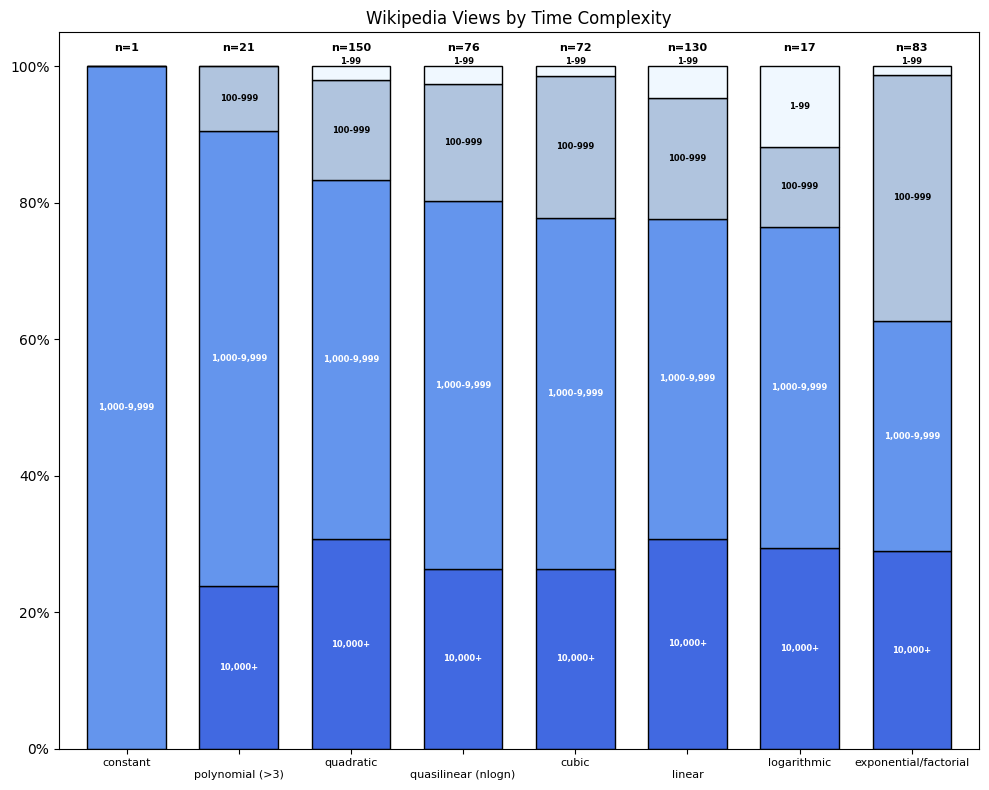

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv('data/merged.csv')
df = df[['average_monthly_reads','Time Complexity Class']]
df['Time Complexity Class'] = df['Time Complexity Class'].replace('#VALUE!', pd.NA)
df['average_monthly_reads'] = df['average_monthly_reads'].fillna(0)
df = df.dropna()

num_bins = 4
df = df.astype(float)
merged_dict = df.to_dict(orient='records')
for algo in merged_dict:
    if algo['Time Complexity Class'] < 2:
        algo['Time Complexity Bin'] = 1
    elif algo['Time Complexity Class'] < 3:
        algo['Time Complexity Bin'] = 2
    elif algo['Time Complexity Class'] < 4:
        algo['Time Complexity Bin'] = 3
    elif algo['Time Complexity Class'] < 5:
        algo['Time Complexity Bin'] = 4
    elif algo['Time Complexity Class'] < 6:
        algo['Time Complexity Bin'] = 5
    elif algo['Time Complexity Class'] < 7:
        algo['Time Complexity Bin'] = 6
    elif algo['Time Complexity Class'] < 8:
        algo['Time Complexity Bin'] = 7
    elif algo['Time Complexity Class'] < 9:
        algo['Time Complexity Bin'] = 8
    
    if (algo['average_monthly_reads'] == 0):
        merged_dict.remove(algo)
    elif (algo['average_monthly_reads'] <100):
        algo['reads_bin'] = 3
    elif algo['average_monthly_reads'] <1000:
        algo['reads_bin'] = 2
    elif algo['average_monthly_reads'] <10000:
        algo['reads_bin'] = 1
    elif algo['average_monthly_reads'] >=10000:
        algo['reads_bin'] = 0
    else:
        merged_dict.remove(algo)

df = pd.DataFrame(merged_dict)

crosstb_prop = pd.crosstab(df["Time Complexity Bin"], df['reads_bin'], normalize="index")
crosstb_prop *= 100
crosstb = pd.crosstab(df["Time Complexity Bin"], df['reads_bin'])

# Define the desired order of rows
new_bin_order = [1, 7, 5, 4, 6, 3, 2, 8]

bin_labels = ['constant', '\npolynomial (>3)', 'quadratic', '\nquasilinear (nlogn)', 'cubic', '\nlinear', 'logarithmic', 'exponential/factorial']

# Reindex the DataFrame
crosstb_prop_reindexed = crosstb_prop.reindex(new_bin_order)
crosstb_reindexed = crosstb.reindex(new_bin_order)

crosstb_prop_reindexed.plot(kind='bar', stacked=True, color=['royalblue', 'cornflowerblue', 'lightsteelblue', 'aliceblue'], edgecolor='black', figsize=(10, 8), width=0.7)

#title and axes
plt.xlabel("Time Complexity")
plt.title('Wikipedia Views by Time Complexity')

# # Set the x-ticks and x-tick labels
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_xlabel('')

ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=8)
ax.get_legend().remove()

for n, x in enumerate([*crosstb_prop_reindexed.index.values]):
    total = 0
    for (proportion, count, y_loc) in zip(crosstb_prop_reindexed.loc[x],
                                          crosstb_reindexed.loc[x],
                                          crosstb_prop_reindexed.loc[x].cumsum()):
        total += count
    plt.text(x=n,
                 y=(y_loc) + 2,
                 s="n=" + str(total), 
                 color="black",
                 ha='center',
                 va='bottom',
                 fontsize=8,
                 fontweight="bold")


y = 0
for n, x in enumerate([*crosstb_prop_reindexed.index.values]):
    total = 0
    for (proportion, count, y_loc) in zip(crosstb_prop_reindexed.loc[x],
                                          crosstb_reindexed.loc[x],
                                          crosstb_prop_reindexed.loc[x].cumsum()):
        if (proportion != 0) & ((y % num_bins == num_bins-1)):
            if (proportion < 5): 
                plt.text(x=n,
                 y=(y_loc),
                 s='1-99', 
                 color="black",
                 ha='center',
                 va='bottom',
                 fontsize=6,
                 fontweight="bold")
            else:
                plt.text(x=n,
                    y=(y_loc - proportion) + (proportion / 2),
                    s='1-99', 
                    color="black",
                    ha='center',
                    va='center',
                    fontsize=6,
                    fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-2)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='100-999', 
                 color="black",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-3)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='1,000-9,999', 
                 color="white",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-4)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='10,000+', 
                 color="white",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        y+=1
plt.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
plt.tight_layout()
ax.set_ylim(0, 105)
plt.savefig('figures/fig3B.pdf')
plt.savefig('figures/fig3B.png')

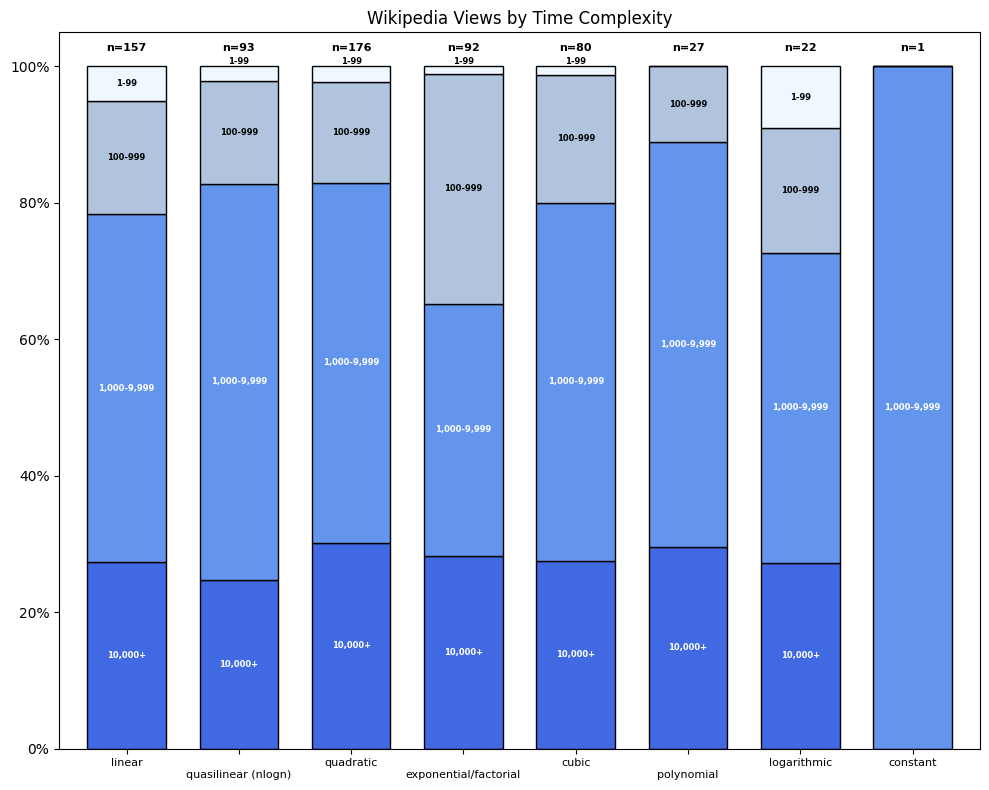

In [103]:
#Option 2
#divide up bars by views

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv('data/merged.csv')
df = df[['average_monthly_reads','Time Complexity Class']]
df = df.replace('#VALUE!', pd.NA).dropna()
num_bins = 4
df = df.astype(float)
merged_dict = df.to_dict(orient='records')
for algo in merged_dict:
    if algo['Time Complexity Class'] < 2:
        algo['Time Complexity Bin'] = 1
    elif algo['Time Complexity Class'] < 3:
        algo['Time Complexity Bin'] = 2
    elif algo['Time Complexity Class'] < 4:
        algo['Time Complexity Bin'] = 3
    elif algo['Time Complexity Class'] < 5:
        algo['Time Complexity Bin'] = 4
    elif algo['Time Complexity Class'] < 6:
        algo['Time Complexity Bin'] = 5
    elif algo['Time Complexity Class'] < 7:
        algo['Time Complexity Bin'] = 6
    elif algo['Time Complexity Class'] < 8:
        algo['Time Complexity Bin'] = 7
    elif algo['Time Complexity Class'] < 9:
        algo['Time Complexity Bin'] = 8
    
    if (algo['average_monthly_reads'] == 0):
        merged_dict.remove(algo)
    elif (algo['average_monthly_reads'] <100):
        algo['reads_bin'] = 3
    elif algo['average_monthly_reads'] <1000:
        algo['reads_bin'] = 2
    elif algo['average_monthly_reads'] <10000:
        algo['reads_bin'] = 1
    elif algo['average_monthly_reads'] >=10000:
        algo['reads_bin'] = 0
    else:
        merged_dict.remove(algo)

df = pd.DataFrame(merged_dict)

crosstb_prop = pd.crosstab(df["Time Complexity Bin"], df['reads_bin'], normalize="index")
crosstb_prop *= 100
crosstb = pd.crosstab(df["Time Complexity Bin"], df['reads_bin'])

# Define the desired order of rows
new_bin_order = [3, 4, 5, 8, 6, 7, 2, 1]

bin_labels = ['linear', '\nquasilinear (nlogn)', 'quadratic', '\nexponential/factorial', 'cubic', '\npolynomial', 'logarithmic', 'constant']

# Reindex the DataFrame
crosstb_prop_reindexed = crosstb_prop.reindex(new_bin_order)
crosstb_reindexed = crosstb.reindex(new_bin_order)

crosstb_prop_reindexed.plot(kind='bar', stacked=True, color=['royalblue', 'cornflowerblue', 'lightsteelblue', 'aliceblue'], edgecolor='black', figsize=(10, 8), width=0.7)

#title and axes
plt.xlabel("Time Complexity")
plt.title('Wikipedia Views by Time Complexity')

# # Set the x-ticks and x-tick labels
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_xlabel('')

ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=8)
ax.get_legend().remove()

for n, x in enumerate([*crosstb_prop_reindexed.index.values]):
    total = 0
    for (proportion, count, y_loc) in zip(crosstb_prop_reindexed.loc[x],
                                          crosstb_reindexed.loc[x],
                                          crosstb_prop_reindexed.loc[x].cumsum()):
        total += count
    plt.text(x=n,
                 y=(y_loc) + 2,
                 s="n=" + str(total), 
                 color="black",
                 ha='center',
                 va='bottom',
                 fontsize=8,
                 fontweight="bold")


y = 0
for n, x in enumerate([*crosstb_prop_reindexed.index.values]):
    total = 0
    for (proportion, count, y_loc) in zip(crosstb_prop_reindexed.loc[x],
                                          crosstb_reindexed.loc[x],
                                          crosstb_prop_reindexed.loc[x].cumsum()):
        if (proportion != 0) & ((y % num_bins == num_bins-1)):
            if (proportion < 5): 
                plt.text(x=n,
                 y=(y_loc),
                 s='1-99', 
                 color="black",
                 ha='center',
                 va='bottom',
                 fontsize=6,
                 fontweight="bold")
            else:
                plt.text(x=n,
                    y=(y_loc - proportion) + (proportion / 2),
                    s='1-99', 
                    color="black",
                    ha='center',
                    va='center',
                    fontsize=6,
                    fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-2)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='100-999', 
                 color="black",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-3)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='1,000-9,999', 
                 color="white",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-4)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='10,000+', 
                 color="white",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        y+=1
plt.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
plt.tight_layout()
ax.set_ylim(0, 105)
plt.savefig('figures/fig3B.pdf')
plt.savefig('figures/fig3B.png')

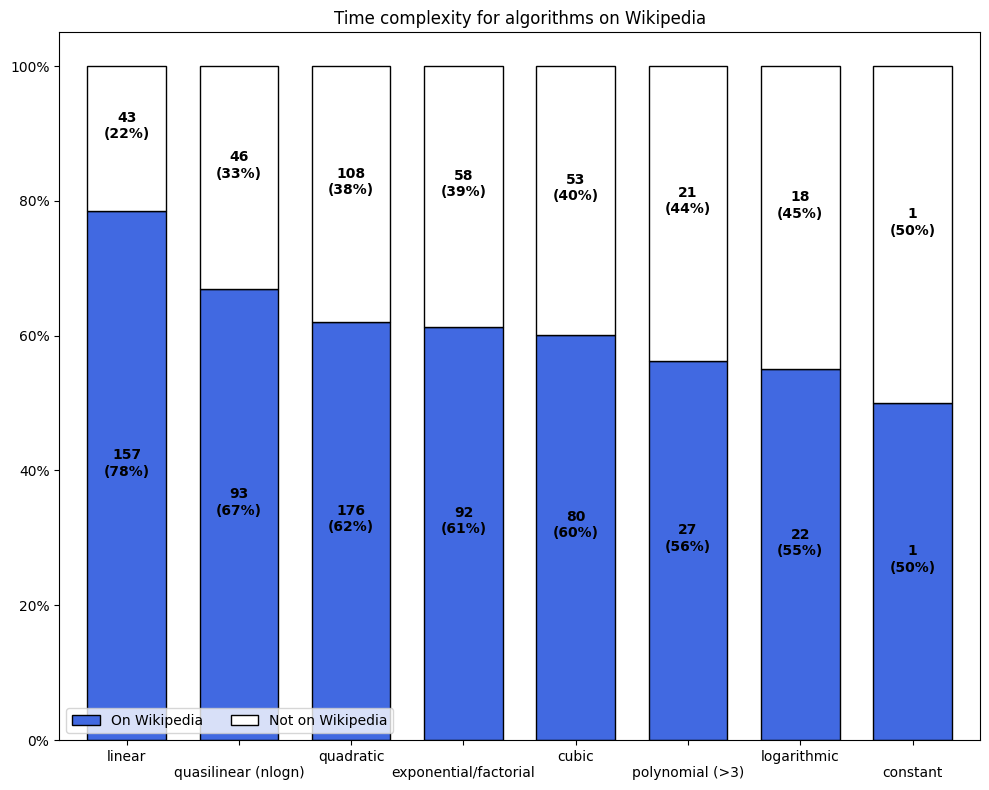

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data/sheet1_output_views.csv')
df = df[['One of them','Time Complexity Class']]
df = df.replace('#VALUE!', pd.NA).dropna()
df['Time Complexity Class'] = df['Time Complexity Class'].astype(float)
merged_dict = df.to_dict(orient='records')
for algo in merged_dict:
    if algo['Time Complexity Class'] < 2:
        algo['Time Complexity Bin'] = 1
    elif algo['Time Complexity Class'] < 3:
        algo['Time Complexity Bin'] = 2
    elif algo['Time Complexity Class'] < 4:
        algo['Time Complexity Bin'] = 3
    elif algo['Time Complexity Class'] < 5:
        algo['Time Complexity Bin'] = 4
    elif algo['Time Complexity Class'] < 6:
        algo['Time Complexity Bin'] = 5
    elif algo['Time Complexity Class'] < 7:
        algo['Time Complexity Bin'] = 6
    elif algo['Time Complexity Class'] < 8:
        algo['Time Complexity Bin'] = 7
    elif algo['Time Complexity Class'] < 9:
        algo['Time Complexity Bin'] = 8
    if algo['One of them'] == 1:
        algo['Not on Wikipedia'] = 0
    elif algo['One of them'] == 0:
        algo['Not on Wikipedia'] = 1

df = pd.DataFrame(merged_dict)

crosstb_prop = pd.crosstab(df["Time Complexity Bin"], df['Not on Wikipedia'], normalize="index")
crosstb_prop *= 100
crosstb = pd.crosstab(df["Time Complexity Bin"], df['Not on Wikipedia'])

crosstb.to_csv('data/results.csv')
crosstb_prop = crosstb_prop.reindex([3,4,5,8,6,7,2,1])
crosstb = crosstb.reindex([3,4,5,8,6,7,2,1])


crosstb_prop.plot(kind='bar', stacked=True, color=['royalblue', 'white'], edgecolor = "black", figsize=(10, 8), width=0.7)

#legend
plt.legend(["On Wikipedia", "Not on Wikipedia"], loc="lower left", ncol=2)

#title and axes
plt.xlabel("")
plt.title('Time complexity for algorithms on Wikipedia')
plt.ylabel("")

bin_labels = ["linear", "\nquasilinear (nlogn)", "quadratic", "\nexponential/factorial", "cubic", "\npolynomial (>3)", "logarithmic", "\nconstant"]

# # Set the x-ticks and x-tick labels
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=0, ha='center')
yticklabels = ax.get_yticklabels()
plt.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)

for n, x in enumerate([*crosstb_prop.index.values]):
    for (proportion, count, y_loc) in zip(crosstb_prop.loc[x],
                                          crosstb.loc[x],
                                          crosstb_prop.loc[x].cumsum()):
                
        plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s=f'{count}\n({int(round(proportion, 0))}%)', 
                 color="black",
                 ha='center',
                 fontsize=10,
                 fontweight="bold")
plt.tight_layout()
plt.savefig('figures/fig3A.pdf')
plt.savefig('figures/fig3A.png')

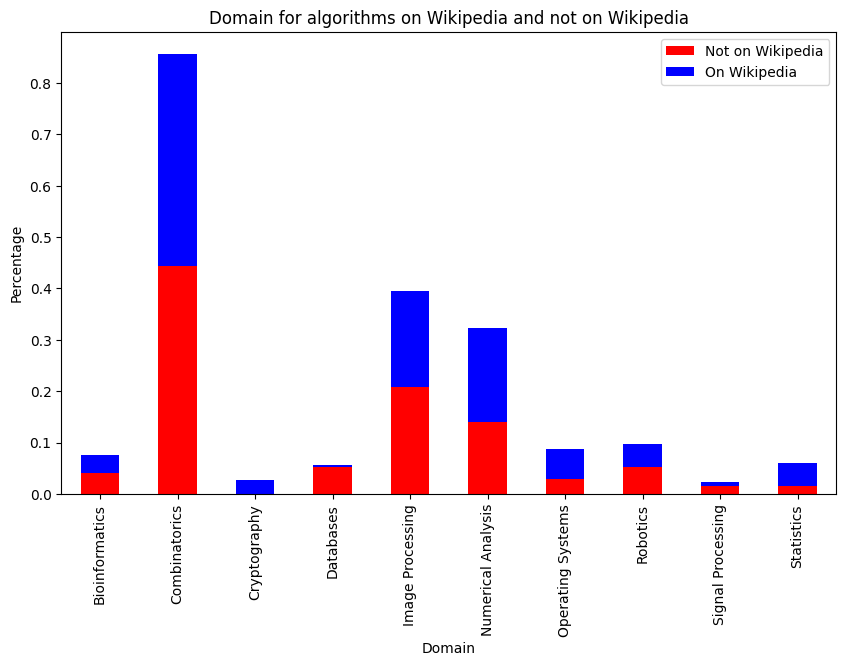

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/merged.csv')

df = df[['One of them','Domains']]
df = df.replace('#VALUE!', pd.NA).dropna()
merged_dict = df.to_dict(orient='records')
df = pd.DataFrame(merged_dict)

grouped = df.groupby(['Domains','One of them']).size().unstack(fill_value=0)
dict = grouped.to_dict()

total_not_in_wiki = dict[0]['Bioinformatics'] + dict[0]['Combinatorics'] + dict[0]['Cryptography'] + dict[0]['Databases'] + dict[0]['Image Processing'] + dict[0]['Numerical Analysis'] + dict[0]['Operating Systems'] + dict[0]['Robotics'] + dict[0]['Signal Processing'] + dict[0]['Statistics']
total_in_wiki = dict[1]['Bioinformatics'] + dict[1]['Combinatorics'] + dict[1]['Cryptography'] + dict[1]['Databases'] + dict[1]['Image Processing'] + dict[1]['Numerical Analysis'] + dict[1]['Operating Systems'] + dict[1]['Robotics'] + dict[1]['Signal Processing'] + dict[1]['Statistics']

grouped[0] = grouped[0] / total_not_in_wiki
grouped[1] = grouped[1] / total_in_wiki


ax = grouped.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'blue'])

plt.xlabel('Domain')
plt.ylabel('Percentage')
plt.title('Domain for algorithms on Wikipedia and not on Wikipedia')

custom_legend_labels = {0: 'Not on Wikipedia', 1: 'On Wikipedia'}
legend = plt.legend(custom_legend_labels.values())
plt.show()


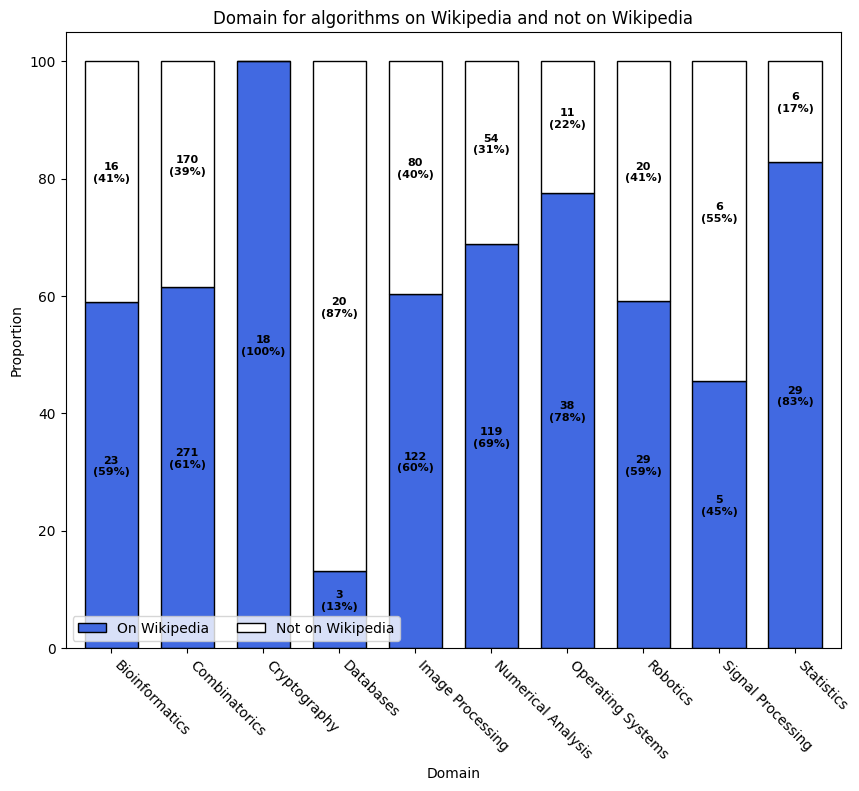

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

df = pd.read_csv('data/sheet1_output_views.csv')
df = df[['One of them','Domains']]
df = df.replace('#VALUE!', pd.NA).dropna()
merged_dict = df.to_dict(orient='records')
for algo in merged_dict:
    if algo['One of them'] == 1:
        algo['Wikipedia?'] = 'On Wikipedia'
    elif algo['One of them'] == 0:
        algo['Wikipedia?'] = 'Not on Wikipedia'

df = pd.DataFrame(merged_dict)

cross_tab = pd.crosstab(index=df['Domains'], columns=df['Wikipedia?'])
cross_tab.to_csv('data/results.csv')

cross_tab_prop = pd.crosstab(index=df['Domains'], columns=df['Wikipedia?'], normalize="index")

cross_tab_prop = cross_tab_prop[['On Wikipedia', 'Not on Wikipedia']]
cross_tab = cross_tab[['On Wikipedia', 'Not on Wikipedia']]

cross_tab_prop *= 100

cross_tab_prop.plot(kind='bar', stacked=True, color=['royalblue', 'white'], edgecolor = "black", figsize=(10, 8), width=0.7)

plt.legend(loc="lower left", ncol=2)
plt.xlabel("Domain")
plt.title("Domain for algorithms on Wikipedia and not on Wikipedia")
plt.ylabel("Proportion")

bin_labels = ["Bioinformatics", "Combinatorics", "Cryptography", "Databases", "Image Processing", "Numerical Analysis", "Operating Systems", "Robotics", "Signal Processing", "Statistics"]
# Set the x-ticks and x-tick labels
ax = plt.gca()
ax.set_xticklabels(bin_labels, rotation=-45, ha='left')

legend_labels = ['On Wikipedia', 'Not on Wikipedia']
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, legend_labels, loc="lower left", ncol=2)

for n, x in enumerate([*cross_tab_prop.index.values]):
    for (proportion, count, y_loc) in zip(cross_tab_prop.loc[x],
                                          cross_tab.loc[x],
                                          cross_tab_prop.loc[x].cumsum()): 
        if proportion != 0 and not proportion == math.nan:
            plt.text(x=n,
                    y=(y_loc - proportion) + (proportion / 2),
                    s=f'{count}\n({int(round(proportion, 0))}%)', 
                    color="black",
                    fontsize=8,
                    ha='center',
                    fontweight="bold")
plt.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
ax.set_ylim(0, 105)
plt.savefig('figures/fig4A.png')
plt.savefig('figures/fig4A.pdf')

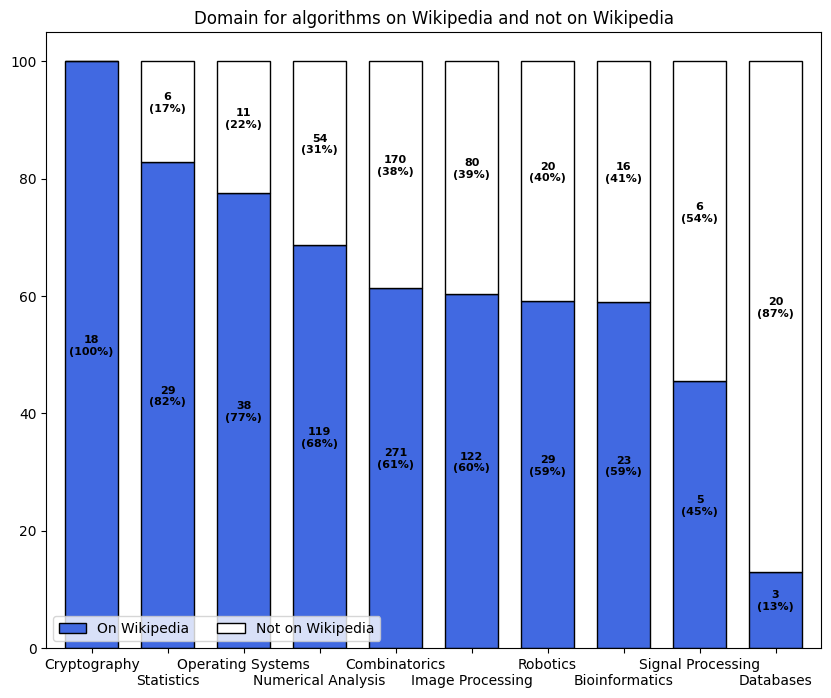

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data/sheet1_output_views.csv')
df = df[['One of them','Domains']]
df = df.replace('#VALUE!', pd.NA).dropna()
merged_dict = df.to_dict(orient='records')
for algo in merged_dict:
    if algo['One of them'] == 1:
        algo['Wikipedia?'] = 'On Wikipedia'
    elif algo['One of them'] == 0:
        algo['Wikipedia?'] = 'Not on Wikipedia'

df = pd.DataFrame(merged_dict)

cross_tab = pd.crosstab(index=df['Domains'], columns=df['Wikipedia?'])
cross_tab.to_csv('data/results.csv')

cross_tab_prop = pd.crosstab(index=df['Domains'], columns=df['Wikipedia?'], normalize="index")

cross_tab_prop = cross_tab_prop[['On Wikipedia', 'Not on Wikipedia']]
cross_tab = cross_tab[['On Wikipedia', 'Not on Wikipedia']]

cross_tab_prop *= 100

cross_tab_prop = cross_tab_prop.reindex(["Cryptography", "Statistics", "Operating Systems", "Numerical Analysis", "Combinatorics", "Image Processing", "Robotics", "Bioinformatics", "Signal Processing", "Databases"])
cross_tab = cross_tab.reindex(["Cryptography", "Statistics", "Operating Systems", "Numerical Analysis", "Combinatorics", "Image Processing", "Robotics", "Bioinformatics", "Signal Processing", "Databases"])

cross_tab_prop.plot(kind='bar', stacked=True, color=['royalblue', 'white'], edgecolor = "black", figsize=(10, 8), width=0.7)

plt.legend(loc="lower left", ncol=2)
plt.xlabel("")
plt.title("Domain for algorithms on Wikipedia and not on Wikipedia")
plt.ylabel("")

bin_labels = ["Cryptography", "\nStatistics", "Operating Systems", "\nNumerical Analysis", "Combinatorics", "\nImage Processing", "Robotics", "\nBioinformatics", "Signal Processing", "\nDatabases"]

# Set the x-ticks and x-tick labels
ax = plt.gca()
# ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=0, ha='center')

legend_labels = ['On Wikipedia', 'Not on Wikipedia']
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, legend_labels, loc="lower left", ncol=2)

for n, x in enumerate([*cross_tab_prop.index.values]):
    for (proportion, count, y_loc) in zip(cross_tab_prop.loc[x],
                                          cross_tab.loc[x],
                                          cross_tab_prop.loc[x].cumsum()): 
        if proportion != 0:
            plt.text(x=n,
                    y=(y_loc - proportion) + (proportion / 2),
                    s=f'{count}\n({int(round(proportion, 1))}%)', 
                    color="black",
                    fontsize=8,
                    ha='center',
                    fontweight="bold")
plt.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
ax.set_ylim(0, 105)

plt.savefig('figures/fig4A.png')
plt.savefig('figures/fig4A.pdf')

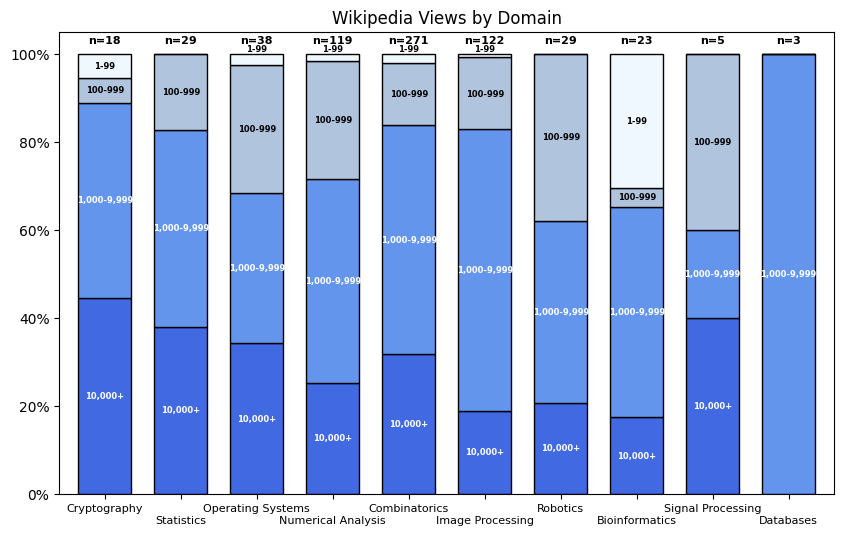

In [108]:
#Option 2
#divide up bars by views

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

df = pd.read_csv('data/merged.csv')
df = df[['average_monthly_reads','Domains']]
df['Domains'] = df['Domains'].replace('#VALUE!', pd.NA)
df['average_monthly_reads'] = df['average_monthly_reads'].fillna(0)
df = df.dropna()
num_bins = 4
merged_dict = df.to_dict(orient='records')
for algo in merged_dict: 
    if algo['average_monthly_reads'] != 0:
        if algo['average_monthly_reads'] <100:
            algo['reads_bin'] = 3
        elif algo['average_monthly_reads'] <1000:
            algo['reads_bin'] = 2
        elif algo['average_monthly_reads'] <10000:
            algo['reads_bin'] = 1
        elif algo['average_monthly_reads'] >=10000:
            algo['reads_bin'] = 0

df = pd.DataFrame(merged_dict)

crosstb_prop = pd.crosstab(df["Domains"], df['reads_bin'], normalize="index")
crosstb_prop *= 100
crosstb = pd.crosstab(df["Domains"], df['reads_bin'])

crosstb_prop = crosstb_prop.reindex(["Cryptography", "Statistics", "Operating Systems", "Numerical Analysis", "Combinatorics", "Image Processing", "Robotics", "Bioinformatics", "Signal Processing", "Databases"])
crosstb = crosstb.reindex(["Cryptography", "Statistics", "Operating Systems", "Numerical Analysis", "Combinatorics", "Image Processing", "Robotics", "Bioinformatics", "Signal Processing", "Databases"])

crosstb_prop.plot(kind='bar', stacked=True, color=['royalblue', 'cornflowerblue', 'lightsteelblue', 'aliceblue'], edgecolor='black', figsize=(10, 6), width=0.7)


#title
plt.title('Wikipedia Views by Domain')


# # Set the x-ticks and x-tick labels
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_xlabel('')

bin_labels = ["Cryptography", "\nStatistics", "Operating Systems", "\nNumerical Analysis", "Combinatorics", "\nImage Processing", "Robotics", "\nBioinformatics", "Signal Processing", "\nDatabases"]
ax.set_xticklabels(bin_labels, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=8)
ax.get_legend().remove()

for n, x in enumerate([*crosstb_prop.index.values]):
    total = 0
    for (proportion, count, y_loc) in zip(crosstb_prop.loc[x],
                                          crosstb.loc[x],
                                          crosstb_prop.loc[x].cumsum()):
        total += count
    plt.text(x=n,
                 y=(y_loc) + 2,
                 s="n=" + str(total), 
                 color="black",
                 ha='center',
                 va='bottom',
                 fontsize=8,
                 fontweight="bold")


y = 0
for n, x in enumerate([*crosstb_prop.index.values]):
    total = 0
    for (proportion, count, y_loc) in zip(crosstb_prop.loc[x],
                                          crosstb.loc[x],
                                          crosstb_prop.loc[x].cumsum()):
        if (proportion < 3) & (proportion != 0) & ((y % num_bins == num_bins-1)):
            plt.text(x=n,
                 y=(y_loc),
                 s='1-99', 
                 color="black",
                 ha='center',
                 va='bottom',
                 fontsize=6,
                 fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-1)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='1-99', 
                 color="black",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-2)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='100-999', 
                 color="black",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-3)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='1,000-9,999', 
                 color="white",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        elif (proportion != 0) & ((y % num_bins == num_bins-4)):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s='10,000+', 
                 color="white",
                 ha='center',
                 va='center',
                 fontsize=6,
                 fontweight="bold")
        y+=1
ax.set_ylim(0, 105)
plt.savefig('figures/fig4B.png')
plt.savefig('figures/fig4B.pdf')

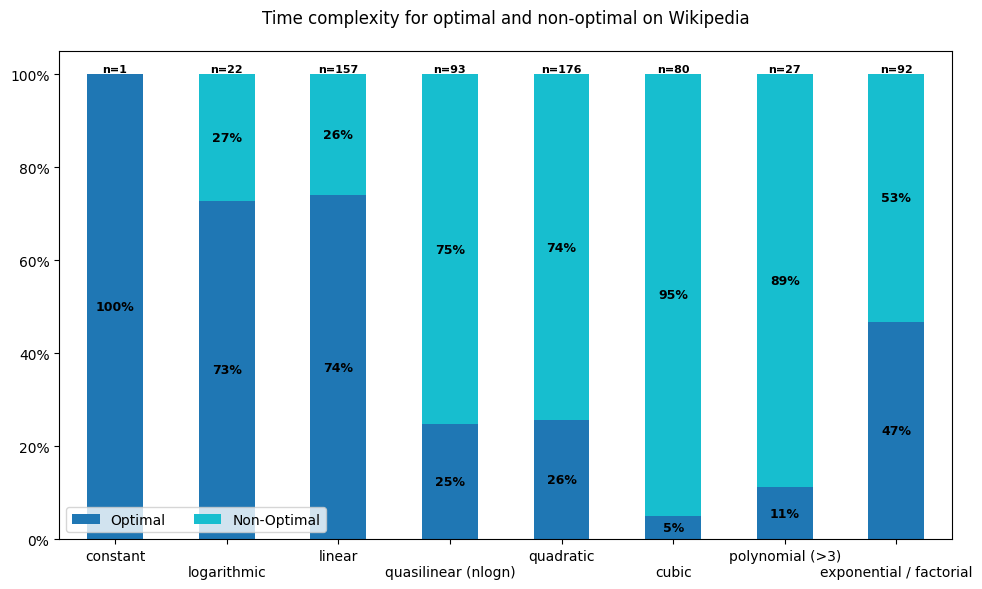

In [109]:
# What fraction of Wikipedia algorithms are optimal by time complexity?

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

df = pd.read_csv('data/merged.csv')
df = df[['One of them','is_optimal','Time Complexity Class']]
df = df.replace('#VALUE!', pd.NA).dropna()
df['Time Complexity Class'] = df['Time Complexity Class'].astype(float)
merged_dict = df.to_dict(orient='records')
for algo in merged_dict:
    if algo['Time Complexity Class'] < 2:
        algo['Time Complexity Bin'] = 1
    elif algo['Time Complexity Class'] < 3:
        algo['Time Complexity Bin'] = 2
    elif algo['Time Complexity Class'] < 4:
        algo['Time Complexity Bin'] = 3
    elif algo['Time Complexity Class'] < 5:
        algo['Time Complexity Bin'] = 4
    elif algo['Time Complexity Class'] < 6:
        algo['Time Complexity Bin'] = 5
    elif algo['Time Complexity Class'] < 7:
        algo['Time Complexity Bin'] = 6
    elif algo['Time Complexity Class'] < 8:
        algo['Time Complexity Bin'] = 7
    elif algo['Time Complexity Class'] < 9:
        algo['Time Complexity Bin'] = 8
    if algo['is_optimal'] == 1:
        algo['optimal?'] = 'Optimal'
    elif algo['is_optimal'] == 0:
        algo['optimal?'] = 'Non-Optimal'
df = pd.DataFrame(merged_dict)
df = df.loc[df['One of them'] == 1]
df.to_csv('data/results.csv')

cross_tab = pd.crosstab(index=df['Time Complexity Bin'], columns=df['optimal?'])
# cross_tab = cross_tab.reindex([1,3,2,8,5,4,7,6])
cross_tab = cross_tab[['Optimal', 'Non-Optimal']]

cross_tab_prop = pd.crosstab(index=df['Time Complexity Bin'], columns=df['optimal?'], normalize="index")
# cross_tab_prop = cross_tab_prop.reindex([1,3,2,8,5,4,7,6])
cross_tab_prop = cross_tab_prop[['Optimal', 'Non-Optimal']]
cross_tab_prop *= 100
cross_tab_prop.to_csv('data/results.csv')

cross_tab_prop.plot(kind='bar', stacked=True, colormap='tab10', figsize=(10, 6))

bin_labels = ['constant', '\nlogarithmic', 'linear', '\nquasilinear (nlogn)', 'quadratic', '\ncubic', 'polynomial (>3)', '\nexponential / factorial']

plt.legend(loc="lower left", ncol=2)
plt.xlabel('')
plt.title('Time complexity for optimal and non-optimal on Wikipedia', pad=20)

# Set the x-ticks and x-tick labels
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=0, ha='center')

legend_labels = ['Optimal', 'Non-Optimal']
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, legend_labels, loc="lower left", ncol=2)

for n, x in enumerate([*cross_tab_prop.index.values]):
    total = 0
    for (proportion, count, y_loc) in zip(cross_tab_prop.loc[x],
                                          cross_tab.loc[x],
                                          cross_tab_prop.loc[x].cumsum()):
        total += count
    plt.text(x=n,
                 y=(y_loc),
                 s="n=" + str(total), 
                 color="black",
                 ha='center',
                 va='bottom',
                 fontsize=8,
                 fontweight="bold")


for n, x in enumerate([*cross_tab_prop.index.values]):
    for (proportion, count, y_loc) in zip(cross_tab_prop.loc[x],
                                          cross_tab.loc[x],
                                          cross_tab_prop.loc[x].cumsum()): 
        if (count != 0):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s=f'{int(round(proportion, 0))}%',  
                 color="black",
                 fontsize=9,
                 ha='center',
                 va='center',
                 fontweight="bold")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('figures/time_complexity_optimal.pdf')

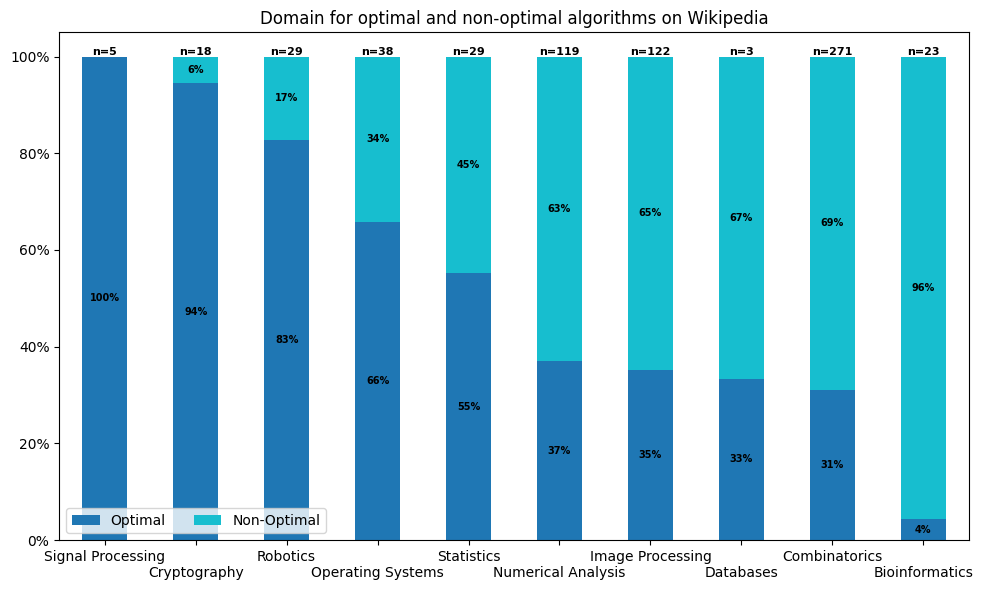

In [110]:
# What fraction of Wikipedia algorithms are optimal by domain?

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

df = pd.read_csv('data/merged.csv')
df = df[['One of them','is_optimal','Domains']]
df = df.replace('#VALUE!', pd.NA).dropna()
merged_dict = df.to_dict(orient='records')
for algo in merged_dict:
    if algo['is_optimal'] == 1:
        algo['optimal?'] = 'Optimal'
    elif algo['is_optimal'] == 0:
        algo['optimal?'] = 'Non-Optimal'
df = pd.DataFrame(merged_dict)
df = df.loc[df['One of them'] == 1]

cross_tab = pd.crosstab(index=df['Domains'], columns=df['optimal?'])
cross_tab = cross_tab.reindex(["Signal Processing", "Cryptography", "Robotics", "Operating Systems", "Statistics", "Numerical Analysis", "Image Processing", "Databases", "Combinatorics", "Bioinformatics"])
cross_tab = cross_tab[['Optimal', 'Non-Optimal']]

cross_tab_prop = pd.crosstab(index=df['Domains'], columns=df['optimal?'], normalize="index")
cross_tab_prop = cross_tab_prop.reindex(["Signal Processing", "Cryptography", "Robotics", "Operating Systems", "Statistics", "Numerical Analysis", "Image Processing", "Databases", "Combinatorics", "Bioinformatics"])
cross_tab_prop = cross_tab_prop[['Optimal', 'Non-Optimal']]
cross_tab_prop *= 100
cross_tab_prop.to_csv('data/results.csv')

cross_tab_prop.plot(kind='bar', stacked=True, colormap='tab10', figsize=(10, 6))

plt.legend(loc="lower left", ncol=2)
plt.xlabel('')
plt.title("Domain for optimal and non-optimal algorithms on Wikipedia")


bin_labels = ["Signal Processing", "\nCryptography", "Robotics", "\nOperating Systems", "Statistics", "\nNumerical Analysis", "Image Processing", "\nDatabases", "Combinatorics", "\nBioinformatics"]

# Set the x-ticks and x-tick labels
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=0, ha='center')

for n, x in enumerate([*cross_tab_prop.index.values]):
    total = 0
    for (proportion, count, y_loc) in zip(cross_tab_prop.loc[x],
                                          cross_tab.loc[x],
                                          cross_tab_prop.loc[x].cumsum()):
        total += count
    plt.text(x=n,
                 y=(y_loc),
                 s="n=" + str(total), 
                 color="black",
                 ha='center',
                 va='bottom',
                 fontsize=8,
                 fontweight="bold")

for n, x in enumerate([*cross_tab_prop.index.values]):
    for (proportion, count, y_loc) in zip(cross_tab_prop.loc[x],
                                          cross_tab.loc[x],
                                          cross_tab_prop.loc[x].cumsum()): 
        if (count != 0):
            plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s=f'{int(round(proportion, 0))}%', 
                 color="black",
                 fontsize=7,
                 ha='center',
                 va='center',
                 fontweight="bold")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

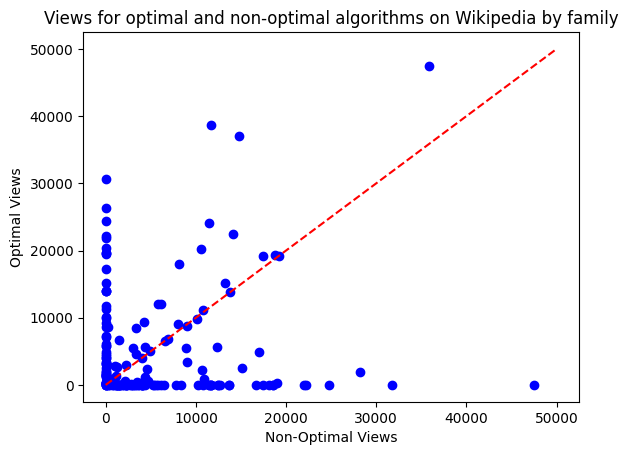

In [111]:
# Average views for optimal vs non-optimal algorithms in each family
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data/merged.csv')
df = df[['One of them','Family Name', 'is_optimal', 'average_monthly_reads']]
df = df.replace('#VALUE!', pd.NA).dropna()
merged_dict = df.to_dict(orient='records')
family = merged_dict[0]['Family Name']
optimal_count = 0
non_optimal_count = 0
optimal_views = 0
non_optimal_views = 0
final_dict = []
for algo in merged_dict:
    if algo['One of them'] == 1:
        if algo['Family Name'] == family:
            if algo['is_optimal'] == True:
                optimal_views += algo['average_monthly_reads']
                optimal_count += 1
            elif algo['is_optimal'] == False:
                non_optimal_views += algo['average_monthly_reads']
                non_optimal_count += 1
        if algo['Family Name'] != family:
            if optimal_count > 0:
                optimal_monthly = optimal_views/optimal_count
            else:
                optimal_monthly = 0
            if non_optimal_count > 0:   
                non_optimal_monthly = non_optimal_views/non_optimal_count
            else:
                non_optimal_monthly = 0
            final_dict.append({'Family Name': family, 'Optimal Monthly Views': optimal_monthly, 'Non-Optimal Monthly Views': non_optimal_monthly})
            family = algo['Family Name']
            optimal_count = 0
            non_optimal_count = 0
            optimal_views = 0
            non_optimal_views = 0
            if algo['is_optimal'] == True:
                optimal_views += algo['average_monthly_reads']
                optimal_count += 1
            elif algo['is_optimal'] == False:
                non_optimal_views += algo['average_monthly_reads']
                non_optimal_count += 1

df = pd.DataFrame(final_dict)


fig, ax = plt.subplots()

# Scatterplot using data from the DataFrame
ax.scatter(df['Non-Optimal Monthly Views'], df['Optimal Monthly Views'], color='blue')

# Create a 45-degree line
x = np.linspace(0, 50000, 100)
y = x

# Plot the 45-degree line
ax.plot(x, y, label='45-Degree Line', color='red', linestyle='--')
plt.title('Views for optimal and non-optimal algorithms on Wikipedia by family')
ax.set_ylabel('Optimal Views')
ax.set_xlabel('Non-Optimal Views')
plt.show()

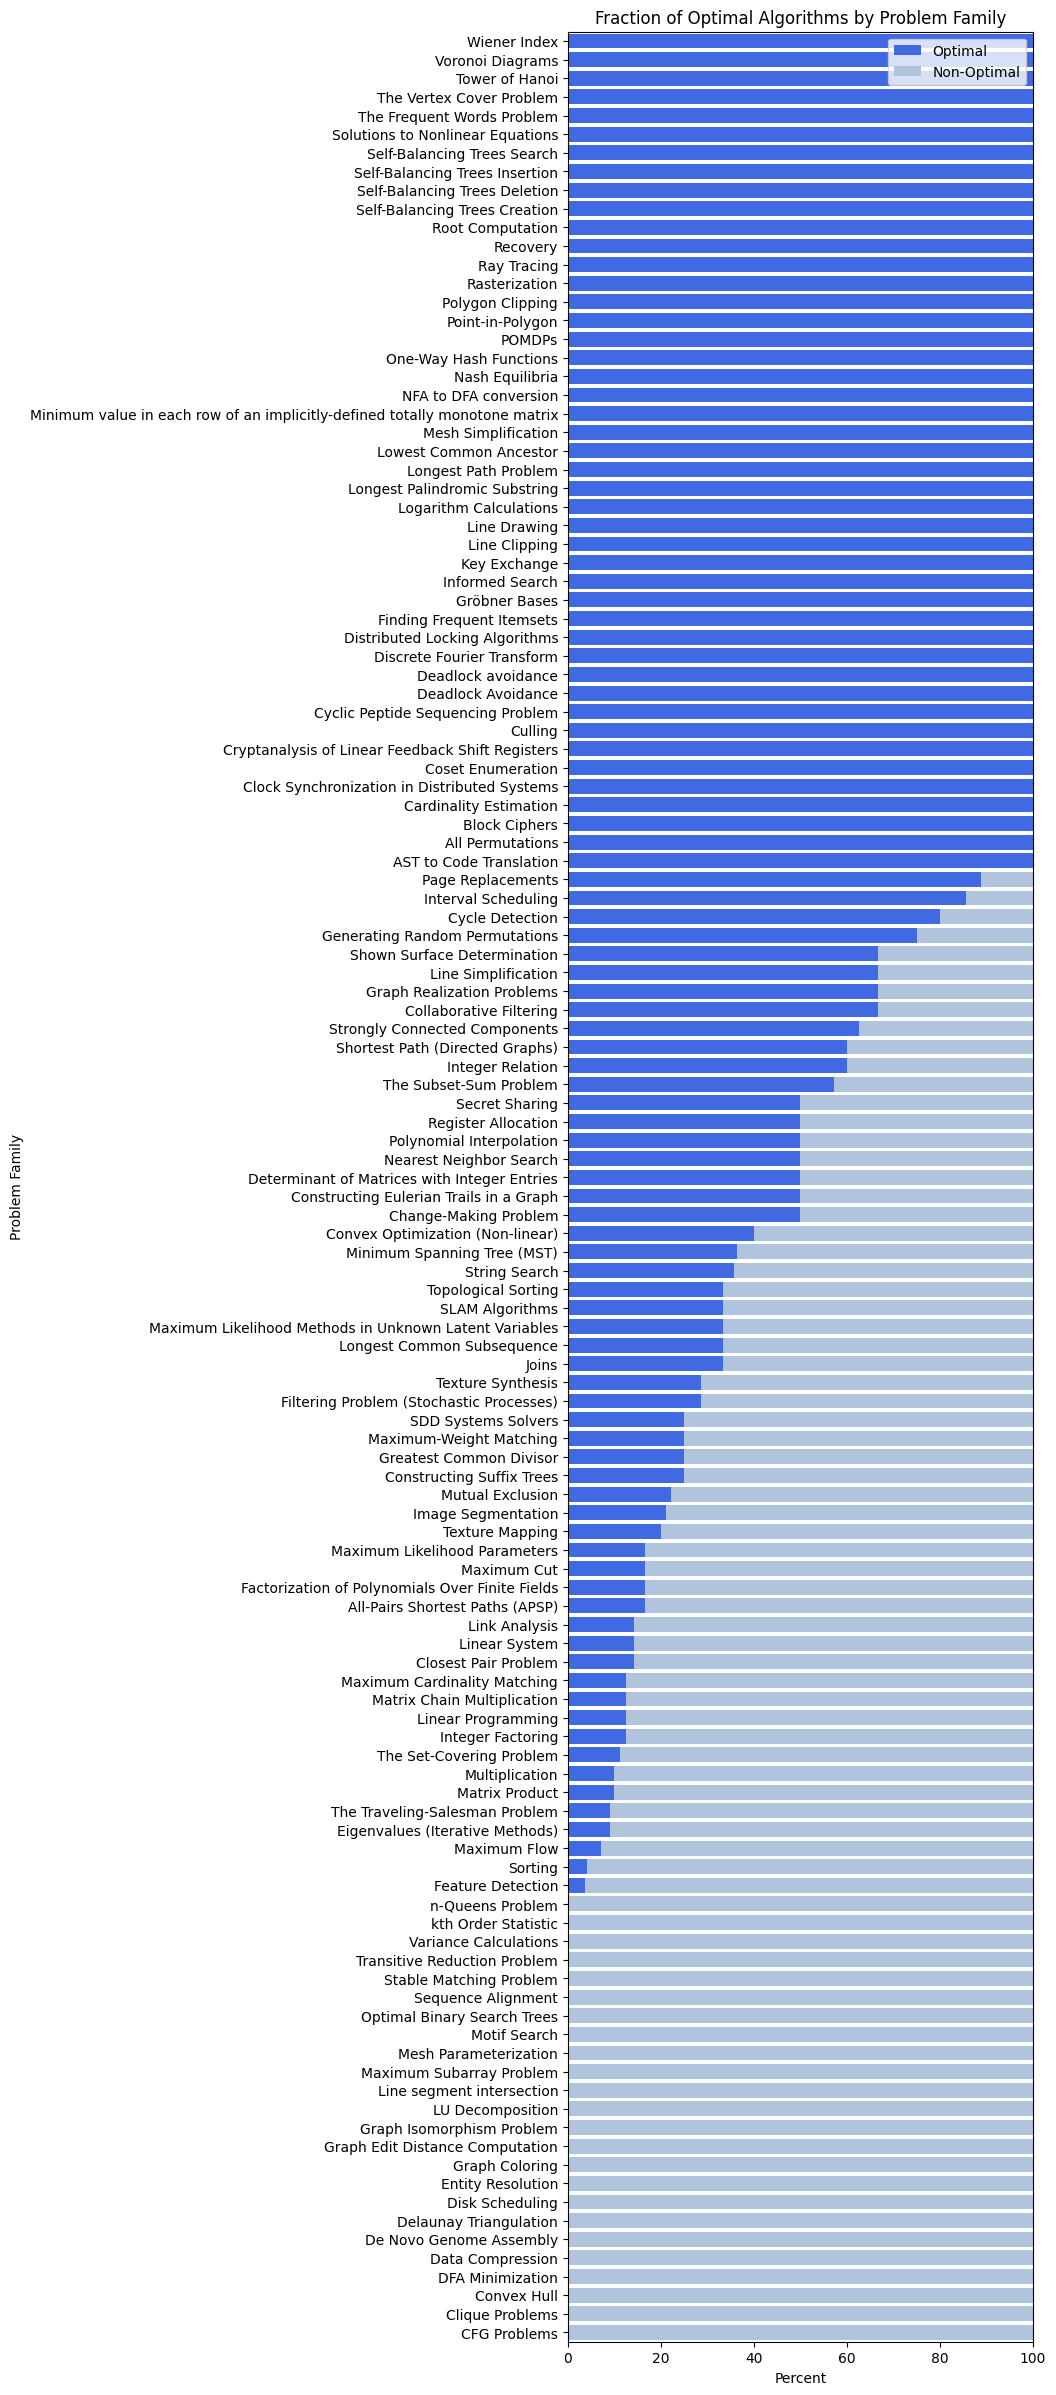

In [112]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data/merged.csv')
df = df[['One of them','Family Name', 'is_optimal', 'average_monthly_reads']]
df = df.replace('#VALUE!', pd.NA).dropna()
merged_dict = df.to_dict(orient='records')

# Sample data
optimal_dict = {}
non_optimal_dict = {}
for algo in merged_dict:
    optimal_dict[algo['Family Name']] = 0
    non_optimal_dict[algo['Family Name']] = 0


for algo in merged_dict:
    if algo["is_optimal"]:
        optimal_dict[algo['Family Name']] += 1
    else:
        non_optimal_dict[algo['Family Name']] += 1

total_optimal = list(optimal_dict.values())
total_non_optimal = list(non_optimal_dict.values())

named_percent_optimal = []
named_percent_non_optimal = []

for key, value in optimal_dict.items():
    named_percent_optimal.append((key, value/(value + non_optimal_dict[key])))
    named_percent_non_optimal.append((key, non_optimal_dict[key]/(value + non_optimal_dict[key])))

named_percent_optimal = sorted(named_percent_optimal, key=lambda x: (x[1], x[0]))
named_percent_non_optimal = sorted(named_percent_non_optimal, key=lambda x: (-x[1], x[0]))

categories = []
percent_optimal = []
percent_non_optimal = []

for i in range(len(named_percent_optimal)):
    percent_optimal.append(named_percent_optimal[i][1]*100)
    percent_non_optimal.append(named_percent_non_optimal[i][1]*100)
    categories.append(named_percent_optimal[i][0])

# Create stacked bar plot
plt.figure(figsize=(6, 30))
plt.barh(categories, percent_optimal, label='Optimal', color='royalblue')
plt.barh(categories, percent_non_optimal, left=percent_optimal, label='Non-Optimal', color='lightsteelblue')

# Add labels and legend
plt.xlabel('Percent')
plt.ylabel('Problem Family')
plt.title('Fraction of Optimal Algorithms by Problem Family')
plt.legend()
plt.ylim(-0.5, len(categories)-0.5)
plt.savefig("figures/fig2_appendix.png", dpi=300, bbox_inches = "tight")
plt.savefig("figures/fig2_appendix.pdf", dpi=300, bbox_inches = "tight")
plt.show()

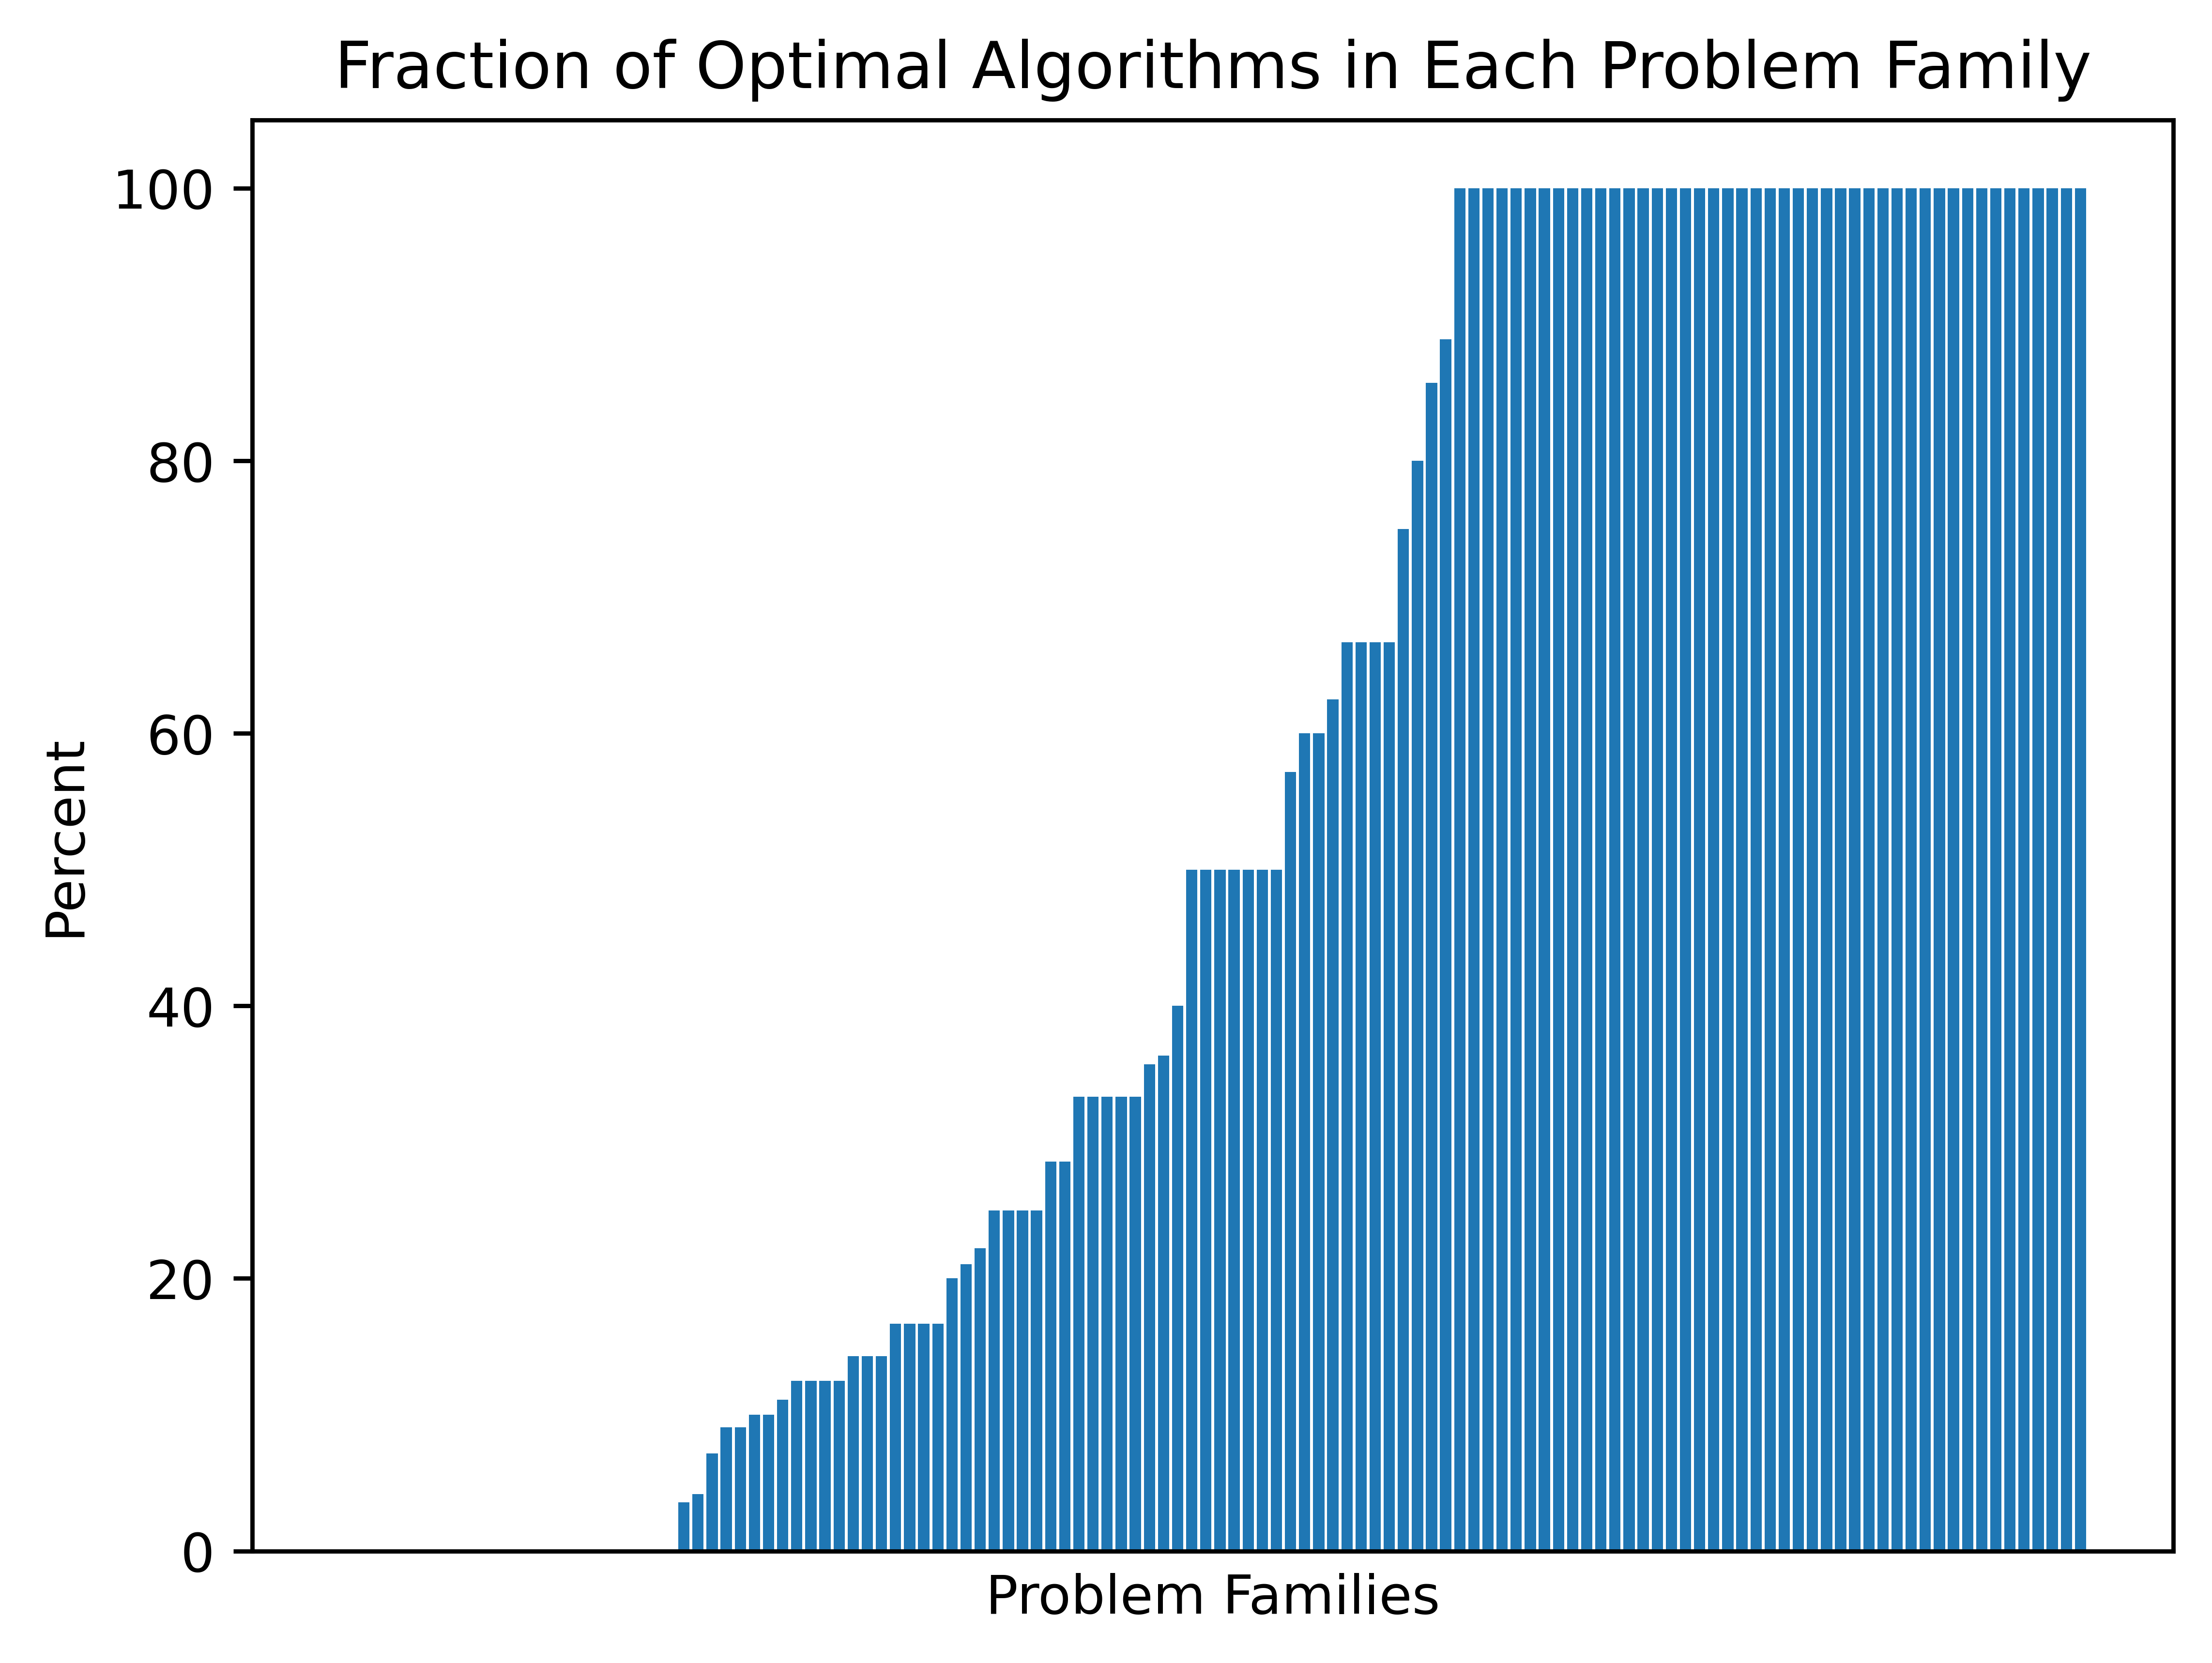

In [113]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data/merged.csv')
df = df[['One of them','Family Name', 'is_optimal', 'average_monthly_reads']]
df = df.replace('#VALUE!', pd.NA).dropna()
merged_dict = df.to_dict(orient='records')

# Sample data
optimal_dict = {}
non_optimal_dict = {}
for algo in merged_dict:
    optimal_dict[algo['Family Name']] = 0
    non_optimal_dict[algo['Family Name']] = 0


for algo in merged_dict:
    if algo["is_optimal"]:
        optimal_dict[algo['Family Name']] += 1
    else:
        non_optimal_dict[algo['Family Name']] += 1

total_optimal = list(optimal_dict.values())
total_non_optimal = list(non_optimal_dict.values())

named_percent_optimal = []
named_percent_non_optimal = []

for key, value in optimal_dict.items():
    named_percent_optimal.append((key, value/(value + non_optimal_dict[key])))
    named_percent_non_optimal.append((key, non_optimal_dict[key]/(value + non_optimal_dict[key])))

named_percent_optimal = sorted(named_percent_optimal, key=lambda x: (x[1], x[0]))
named_percent_non_optimal = sorted(named_percent_non_optimal, key=lambda x: (-x[1], x[0]))

categories = []
percent_optimal = []
percent_non_optimal = []

for i in range(len(named_percent_optimal)):
    percent_optimal.append(named_percent_optimal[i][1] * 100)
    percent_non_optimal.append(named_percent_non_optimal[i][1])
    categories.append(named_percent_optimal[i][0])

# Create stacked bar plot
plt.figure(figsize = (6.4, 4.8), dpi= 800)
plt.bar(categories, percent_optimal)

# Add labels and legend
plt.xticks([])
plt.xlabel('Problem Families')
plt.ylabel('Percent')
plt.title('Fraction of Optimal Algorithms in Each Problem Family')
plt.savefig("figures/fig2_option1")
plt.show()

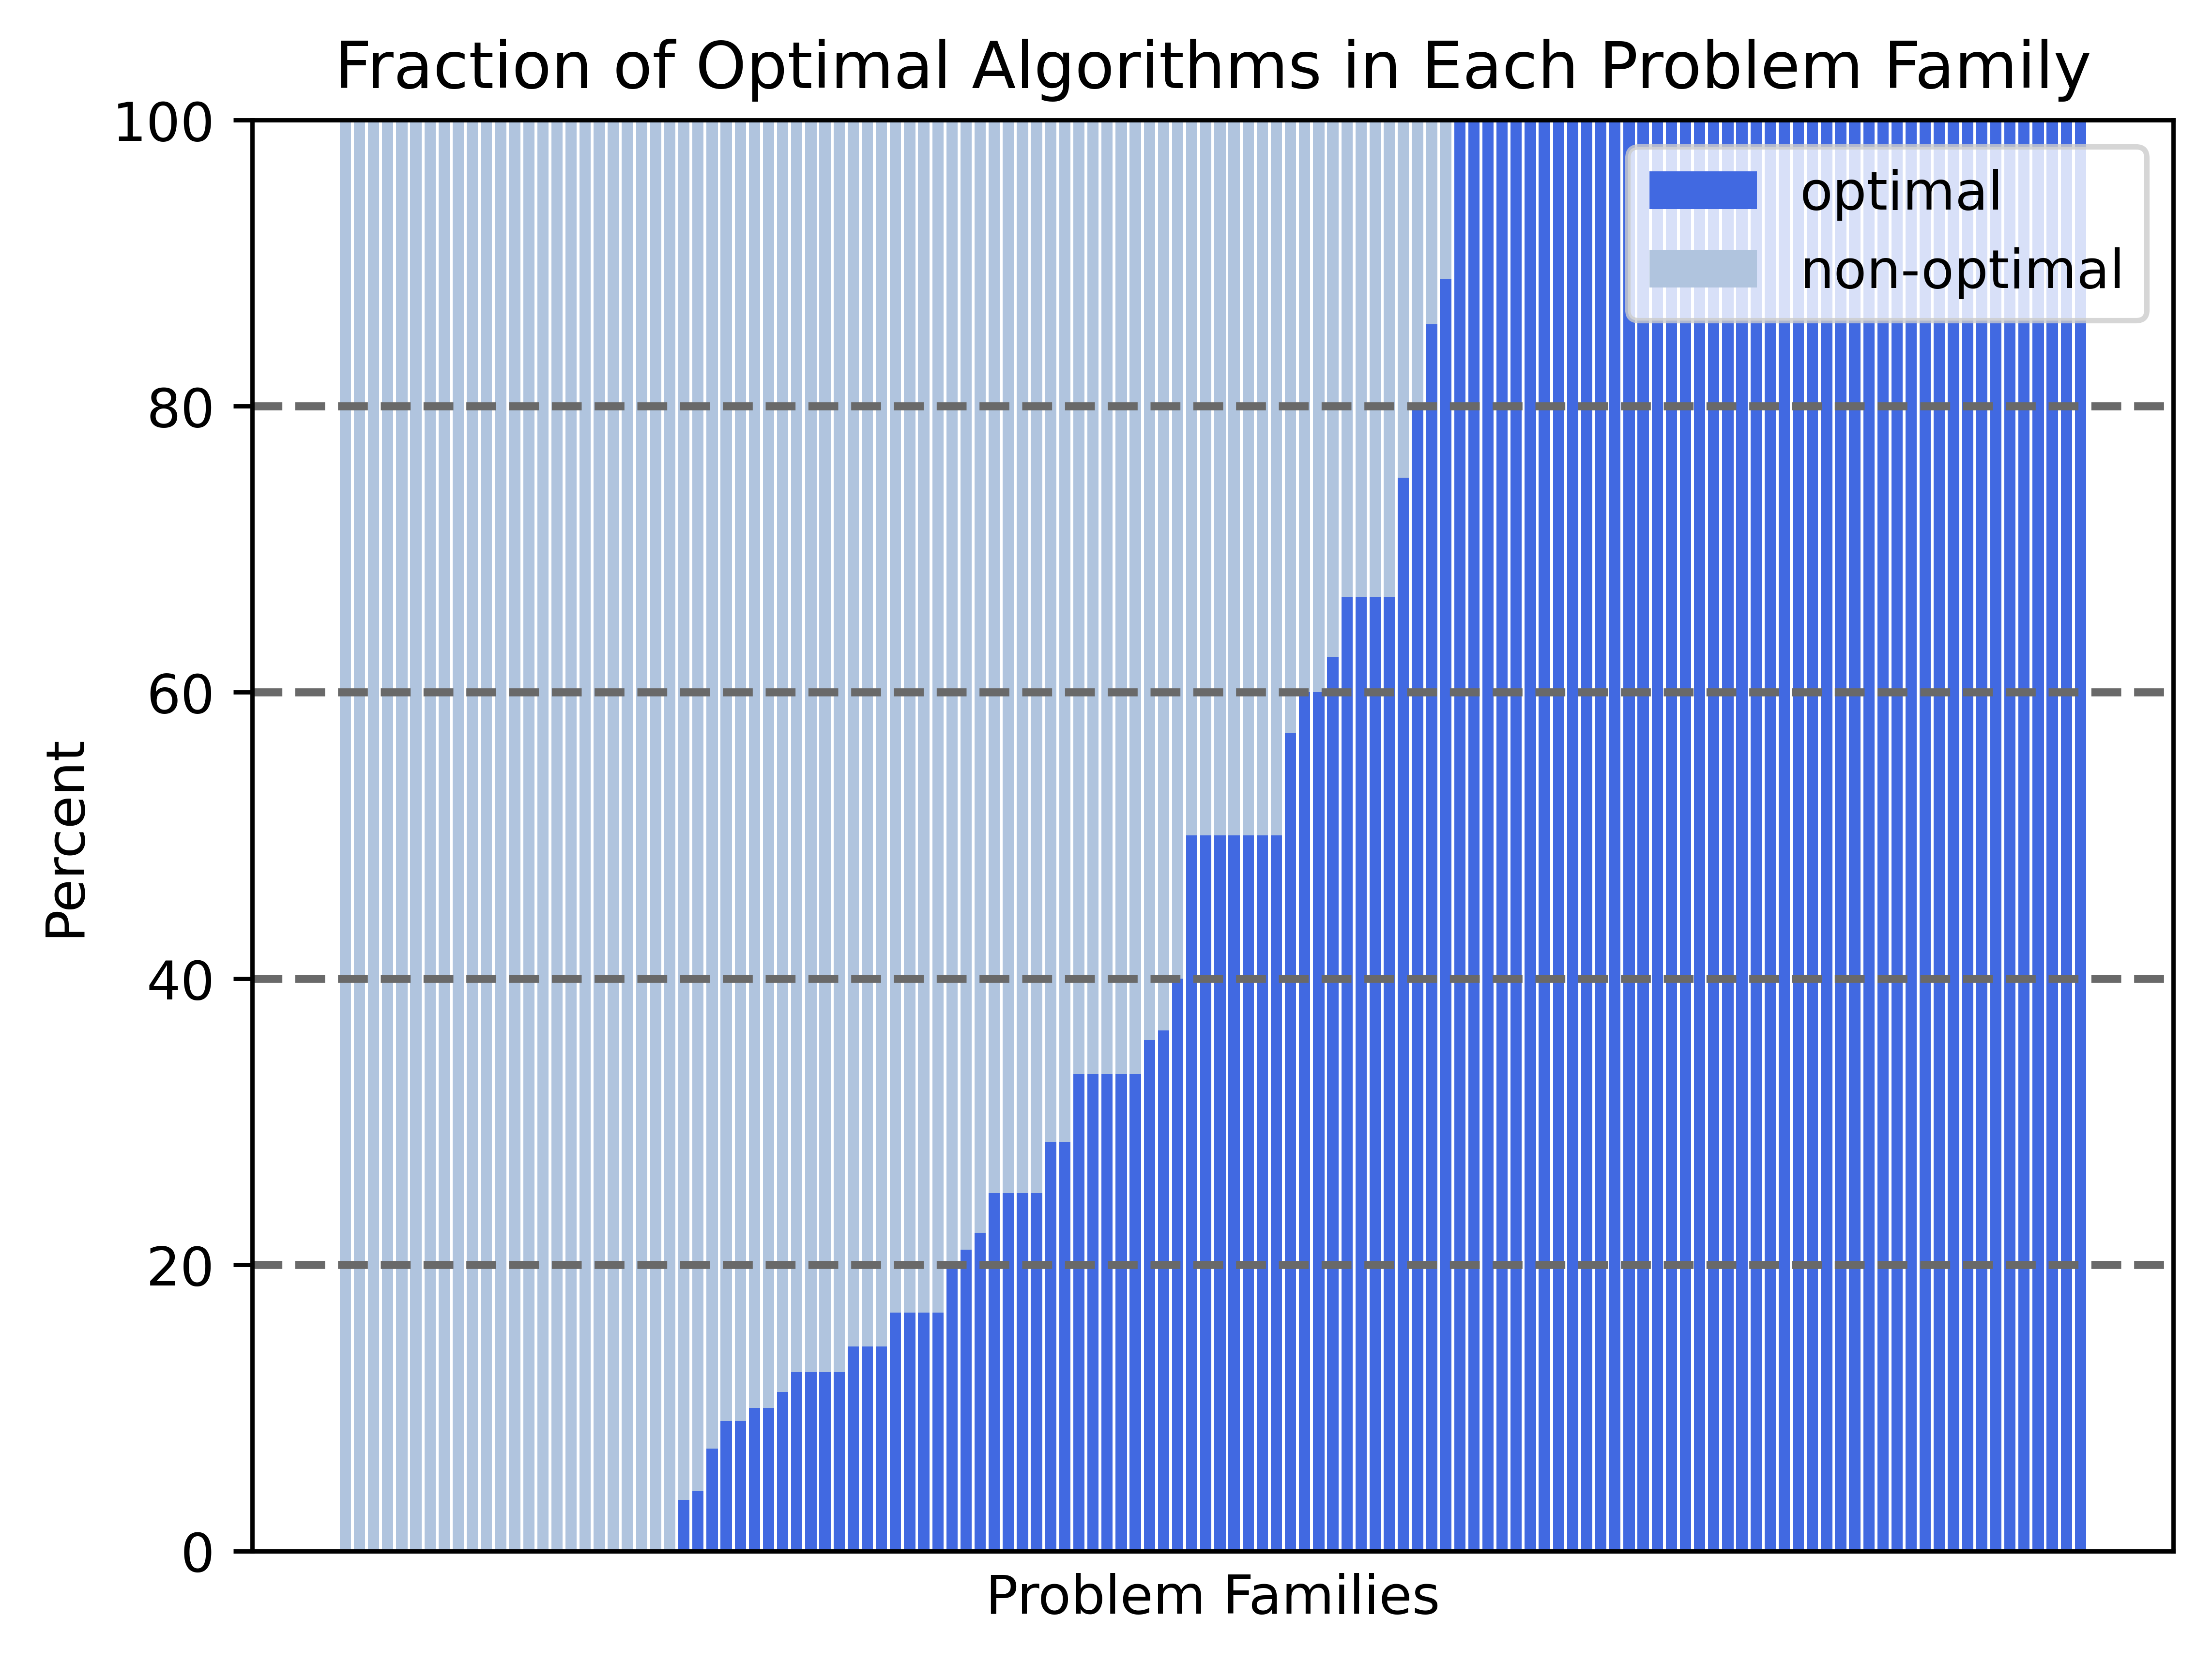

In [114]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data/merged.csv')
df = df[['One of them','Family Name', 'is_optimal', 'average_monthly_reads']]
df = df.replace('#VALUE!', pd.NA).dropna()
merged_dict = df.to_dict(orient='records')

# Sample data
optimal_dict = {}
non_optimal_dict = {}
for algo in merged_dict:
    optimal_dict[algo['Family Name']] = 0
    non_optimal_dict[algo['Family Name']] = 0


for algo in merged_dict:
    if algo["is_optimal"]:
        optimal_dict[algo['Family Name']] += 1
    else:
        non_optimal_dict[algo['Family Name']] += 1

total_optimal = list(optimal_dict.values())
total_non_optimal = list(non_optimal_dict.values())

named_percent_optimal = []
named_percent_non_optimal = []

for key, value in optimal_dict.items():
    named_percent_optimal.append((key, value/(value + non_optimal_dict[key])))
    named_percent_non_optimal.append((key, non_optimal_dict[key]/(value + non_optimal_dict[key])))

named_percent_optimal = sorted(named_percent_optimal, key=lambda x: (x[1], x[0]))
named_percent_non_optimal = sorted(named_percent_non_optimal, key=lambda x: (-x[1], x[0]))

categories = []
percent_optimal = []
percent_non_optimal = []

for i in range(len(named_percent_optimal)):
    percent_optimal.append(named_percent_optimal[i][1] * 100)
    percent_non_optimal.append(named_percent_non_optimal[i][1] * 100)
    categories.append(named_percent_optimal[i][0])

# Create stacked bar plot
plt.figure(figsize = (6.4, 4.8), dpi= 800)
plt.bar(categories, percent_optimal, color='royalblue')
plt.bar(categories, percent_non_optimal, bottom = percent_optimal, color='lightsteelblue')

# Add labels and legend
plt.xticks([])
plt.legend(["optimal", "non-optimal"])
plt.axhline(20, linestyle='--', color='dimgray')
plt.axhline(40, linestyle='--', color='dimgray')
plt.axhline(60, linestyle='--', color='dimgray')
plt.axhline(80, linestyle='--', color='dimgray')
plt.xlabel('Problem Families')
plt.ylabel('Percent')
plt.title('Fraction of Optimal Algorithms in Each Problem Family')
plt.savefig("figures/fig2.pdf")
plt.savefig("figures/fig2.png")
plt.show()

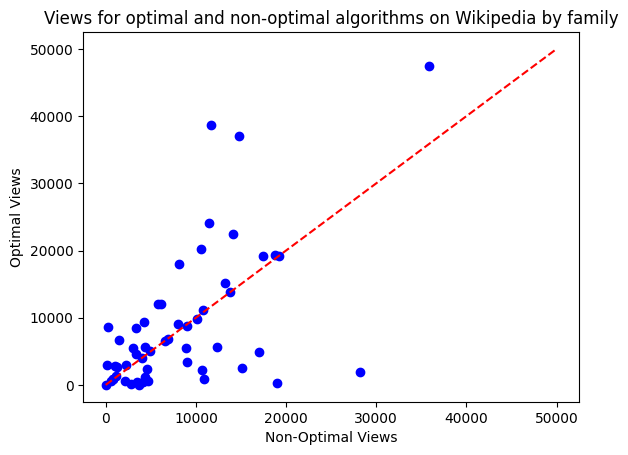

In [115]:
# Average views for optimal vs non-optimal algorithms in each family
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data/merged.csv')
df = df[['One of them','Family Name', 'is_optimal', 'average_monthly_reads']]
df = df.replace('#VALUE!', pd.NA).dropna()
merged_dict = df.to_dict(orient='records')
family = merged_dict[0]['Family Name']
optimal_count = 0
non_optimal_count = 0
optimal_views = 0
non_optimal_views = 0
final_dict = []
for algo in merged_dict:
    if algo['One of them'] == 1:
        if algo['Family Name'] == family:
            if algo['is_optimal'] == True:
                optimal_views += algo['average_monthly_reads']
                optimal_count += 1
            elif algo['is_optimal'] == False:
                non_optimal_views += algo['average_monthly_reads']
                non_optimal_count += 1
        if algo['Family Name'] != family:
            if optimal_count > 0 and non_optimal_count > 0:
                optimal_monthly = optimal_views/optimal_count  
                non_optimal_monthly = non_optimal_views/non_optimal_count
                final_dict.append({'Family Name': family, 'Optimal Monthly Views': optimal_monthly, 'Non-Optimal Monthly Views': non_optimal_monthly})
            family = algo['Family Name']
            optimal_count = 0
            non_optimal_count = 0
            optimal_views = 0
            non_optimal_views = 0
            if algo['is_optimal'] == True:
                optimal_views += algo['average_monthly_reads']
                optimal_count += 1
            elif algo['is_optimal'] == False:
                non_optimal_views += algo['average_monthly_reads']
                non_optimal_count += 1

df = pd.DataFrame(final_dict)


fig, ax = plt.subplots()

# Scatterplot using data from the DataFrame
ax.scatter(df['Non-Optimal Monthly Views'], df['Optimal Monthly Views'], color='blue')

# Create a 45-degree line
x = np.linspace(0, 50000, 100)  # Adjust the range as needed
y = x  # y = x for a 45-degree line

# Plot the 45-degree line
ax.plot(x, y, label='45-Degree Line', color='red', linestyle='--')
plt.title('Views for optimal and non-optimal algorithms on Wikipedia by family')
ax.set_ylabel('Optimal Views')
ax.set_xlabel('Non-Optimal Views')
plt.savefig('figures/views_optimal_algos2.pdf')

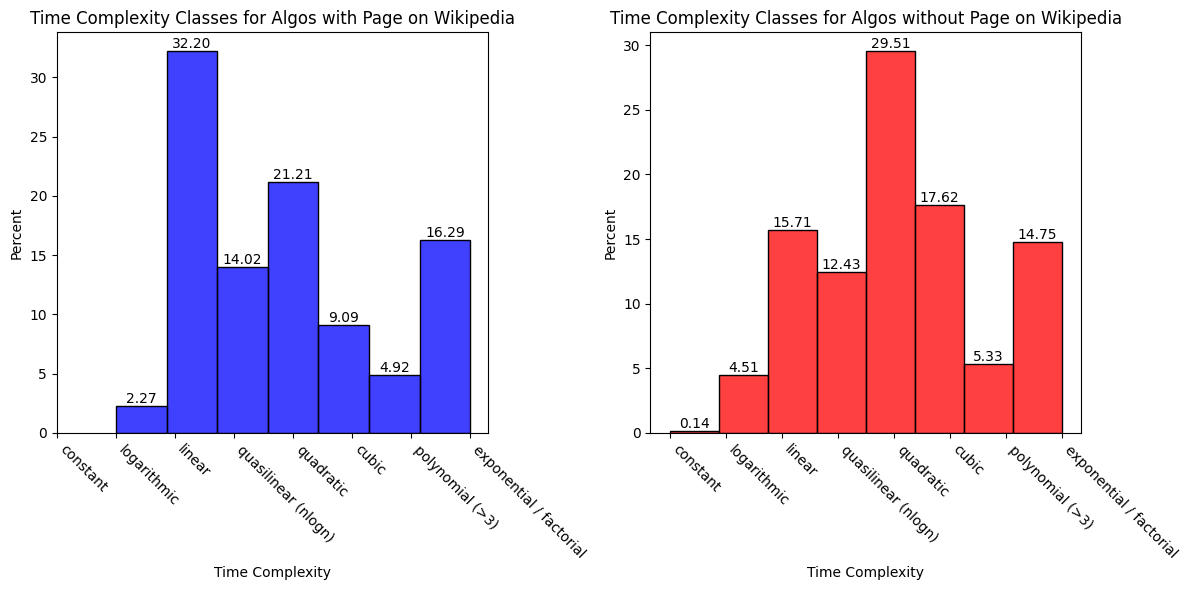

KS Statistic: 0.16703924490809738
P-value: 3.335804867991863e-05
The two datasets are significantly different (reject the null hypothesis)


In [116]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance
from scipy.stats import chi2_contingency

df = pd.read_csv('data/merged.csv')
merged_dict = df.to_dict(orient='records')

wiki_complexity_classes = []
non_wiki_complexity_classes = []
for algo in merged_dict:
    if algo['Time Complexity Class'] != '#VALUE!':
        if algo['Has dedicated page?'] == 1:
            wiki_complexity_classes.append(float(algo['Time Complexity Class']))
            if algo['Time Complexity Class'] == 1:
                print(algo)
        else:
            non_wiki_complexity_classes.append(float(algo['Time Complexity Class']))

bin_edges = [1, 2, 3, 4, 5, 6, 7, 8]
bin_labels = ['constant', 'logarithmic', 'linear', 'quasilinear (nlogn)', 'quadratic', 'cubic', 'polynomial (>3)', 'exponential / factorial']

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Plot the histogram for wiki_complexity_classes
ax1 = sns.histplot(wiki_complexity_classes, kde=False, bins=7, stat='percent', color='blue', edgecolor='black', ax=axes[0])
ax1.set_title('Time Complexity Classes for Algos with Page on Wikipedia')
ax1.set_xlabel('Time Complexity')
ax1.set_ylabel('Percent')
ax1.set_xticks(bin_edges)
ax1.set_xticklabels(bin_labels, rotation=-45, ha='left')

# Add heights (percentages) on top of bars in the first subplot
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

# Plot the histogram for non_wiki_complexity_classes
ax2 = sns.histplot(non_wiki_complexity_classes, kde=False, bins=8, stat='percent', color='red', edgecolor='black', ax=axes[1])
ax2.set_title('Time Complexity Classes for Algos without Page on Wikipedia')
ax2.set_xlabel('Time Complexity')
ax2.set_ylabel('Percent')
ax2.set_xticks(bin_edges)
ax2.set_xticklabels(bin_labels, rotation=-45, ha='left')

# Add heights (percentages) on top of bars in the second subplot
for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Perform K-S test:
ks_statistic, p_value = ks_2samp(wiki_complexity_classes, non_wiki_complexity_classes)

print("KS Statistic:", ks_statistic)
print("P-value:", p_value)

alpha = 0.05  # Significance level
if p_value < alpha:
    print("The two datasets are significantly different (reject the null hypothesis)")
else:
    print("There is no significant difference between the two datasets (fail to reject the null hypothesis)")

In [117]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/merged.csv')
merged_dict = df.to_dict(orient='records')

linear_algos = []

for algo in merged_dict:
    if str(algo['One of them']) == '1':
        if str(algo['Time Complexity Class']) == '3':
            linear_algos.append(algo)
            df = pd.DataFrame(linear_algos)
            df.to_csv('data/linearalgos.csv', index=False)

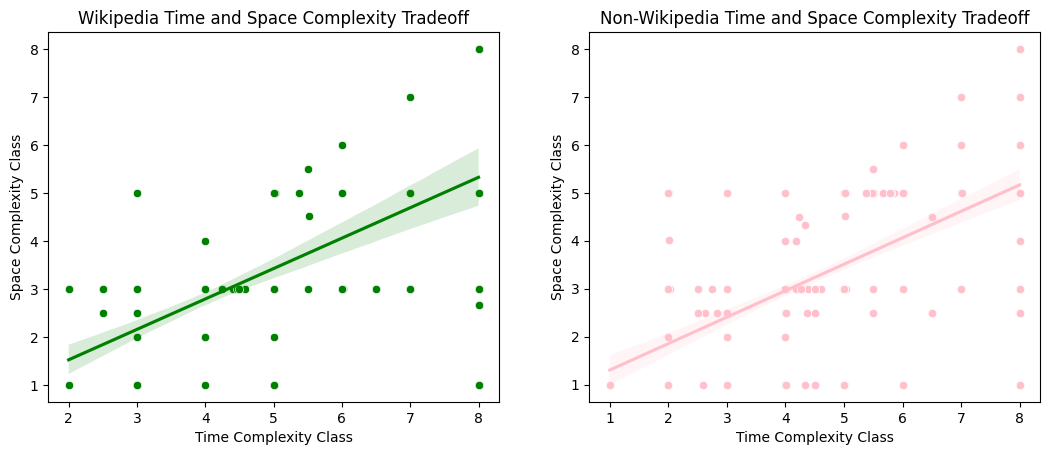

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('data/merged.csv')
merged_dict = df.to_dict(orient='records')

df = df[['Time Complexity Class', 'Space Complexity Class', 'Has dedicated page?']]
df['Time Complexity Class'] = df['Time Complexity Class'].replace('#VALUE!', pd.NA)
df['Space Complexity Class'] = df['Space Complexity Class'].replace('#VALUE!', pd.NA)
df = df.dropna()

# change the type to a float
df['Time Complexity Class'] = df['Time Complexity Class'].astype(float)
df['Space Complexity Class'] = df['Space Complexity Class'].astype(float)

df_wiki = df[df['Has dedicated page?'] == 1]
df_non_wiki = df[df['Has dedicated page?'] == 0]

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.8))

# Scatter plots
sns.scatterplot(x='Time Complexity Class', y='Space Complexity Class', data=df_wiki, color='green', ax=ax1)
sns.scatterplot(x='Time Complexity Class', y='Space Complexity Class', data=df_non_wiki, color='pink', ax=ax2)

# Regression lines
sns.regplot(x='Time Complexity Class', y='Space Complexity Class', data=df_wiki, scatter=False, color='green', ax=ax1)
sns.regplot(x='Time Complexity Class', y='Space Complexity Class', data=df_non_wiki, scatter=False, color='pink', ax=ax2)

# Set titles and labels
ax1.set_title("Wikipedia Time and Space Complexity Tradeoff")
ax2.set_title("Non-Wikipedia Time and Space Complexity Tradeoff")

ax1.set_xlabel("Time Complexity Class")
ax1.set_ylabel("Space Complexity Class")

ax2.set_xlabel("Time Complexity Class")
plt.savefig('figures/time_space_tradeoff1.pdf')

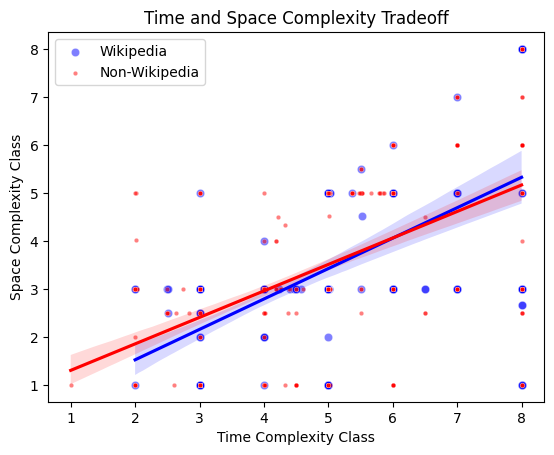

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('data/merged.csv')
merged_dict = df.to_dict(orient='records')

df = df[['Time Complexity Class', 'Space Complexity Class', 'Has dedicated page?']]
df['Time Complexity Class'] = df['Time Complexity Class'].replace('#VALUE!', pd.NA)
df['Space Complexity Class'] = df['Space Complexity Class'].replace('#VALUE!', pd.NA)
df = df.dropna()

# change the type to a float
df['Time Complexity Class'] = df['Time Complexity Class'].astype(float)
df['Space Complexity Class'] = df['Space Complexity Class'].astype(float)

df_wiki = df[df['Has dedicated page?'] == 1]
df_non_wiki = df[df['Has dedicated page?'] == 0]

# Create the scatter plot
plt.figure(figsize=(6.4, 4.8))

# Scatter plots with adjusted transparency (alpha)
sns.scatterplot(x='Time Complexity Class', y='Space Complexity Class', data=df_wiki, color='blue', label='Wikipedia', alpha=0.5)
sns.scatterplot(x='Time Complexity Class', y='Space Complexity Class', data=df_non_wiki, color='red', label='Non-Wikipedia', alpha=0.5, s=10)

# Regression lines
sns.regplot(x='Time Complexity Class', y='Space Complexity Class', data=df_wiki, scatter=False, color='blue')
sns.regplot(x='Time Complexity Class', y='Space Complexity Class', data=df_non_wiki, scatter=False, color='red')

# Set title and labels
plt.title("Time and Space Complexity Tradeoff")
plt.xlabel("Time Complexity Class")
plt.ylabel("Space Complexity Class")

# Display legend
plt.legend()
plt.savefig('figures/time_space_tradeoff2.pdf')

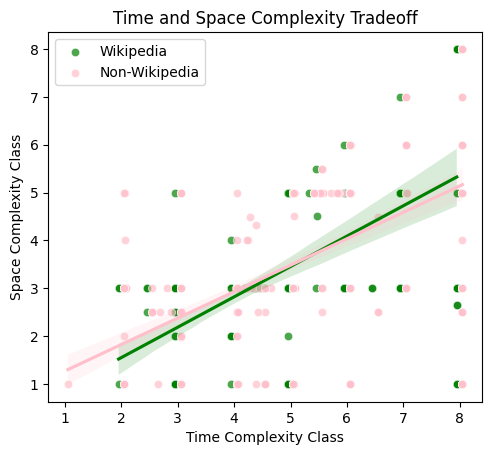

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('data/merged.csv')
merged_dict = df.to_dict(orient='records')

df = df[['Time Complexity Class', 'Space Complexity Class', 'Has dedicated page?']]
df['Time Complexity Class'] = df['Time Complexity Class'].replace('#VALUE!', pd.NA)
df['Space Complexity Class'] = df['Space Complexity Class'].replace('#VALUE!', pd.NA)
df = df.dropna()

# change the type to a float
df['Time Complexity Class'] = df['Time Complexity Class'].astype(float)
df['Space Complexity Class'] = df['Space Complexity Class'].astype(float)

df_wiki = df[df['Has dedicated page?'] == 1]
df_non_wiki = df[df['Has dedicated page?'] == 0]

# Shift all points in the non-Wikipedia plot to the right by adding a constant value
shift_value = 0.05
df_non_wiki['Time Complexity Class'] += shift_value
df_wiki['Time Complexity Class'] -= shift_value

# Create the scatter plot
plt.figure(figsize=(5.6, 4.8))

# Scatter plot for Wikipedia data points
sns.scatterplot(x='Time Complexity Class', y='Space Complexity Class', data=df_wiki, color='green', label='Wikipedia', alpha=0.7)

# Scatter plot for Non-Wikipedia data points with smaller size and shifted to the right
sns.scatterplot(x='Time Complexity Class', y='Space Complexity Class', data=df_non_wiki, color='pink', label='Non-Wikipedia', alpha=0.7)

# Regression lines
sns.regplot(x='Time Complexity Class', y='Space Complexity Class', data=df_wiki, scatter=False, color='green')
sns.regplot(x='Time Complexity Class', y='Space Complexity Class', data=df_non_wiki, scatter=False, color='pink')

# Set title and labels
plt.title("Time and Space Complexity Tradeoff")
plt.xlabel("Time Complexity Class")
plt.ylabel("Space Complexity Class")

# Display legend
plt.legend()
plt.savefig('figures/time_space_tradeoff3.pdf')

In [121]:
import pandas as pd
optimal_algos = {}
clean_dict = {}

def change_duplicate_names():
    df = pd.read_csv('data/merged.csv')
    df = df[['Time Complexity Class', 'Space Complexity Class', 'Family Name', 'Algorithm Name', 'One of them', 'is_optimal']]
    df['Time Complexity Class'] = df['Time Complexity Class'].replace('#VALUE!', pd.NA)
    df['Space Complexity Class'] = df['Space Complexity Class'].replace('#VALUE!', pd.NA)
    df = df.dropna()
    merged_dict = df.to_dict(orient='records')
    # print(merged_dict)
    algo_list = []
    index = 0
    count = 1
    for algo in merged_dict:
        if algo['Algorithm Name'] not in algo_list:
            algo_list.append(algo['Algorithm Name'])
        else:
            merged_dict[index] = {'Time Complexity Class': algo['Time Complexity Class'], 'Space Complexity Class': algo['Space Complexity Class'], 'Family Name': algo['Family Name'], 'Algorithm Name': algo['Algorithm Name'] + ' ' + str(count), 'One of them': algo['One of them'], 'is_optimal': algo['is_optimal']}
            algo_list.append('Algorithm Name' + ' ' + str(count))
            count += 1
        index += 1
    return merged_dict

def clean_data(merged_dict):
    for algo in merged_dict:
        clean_dict[algo['Algorithm Name']] = {'Time Complexity Class': algo['Time Complexity Class'], 'Space Complexity Class': algo['Space Complexity Class'], 'Family Name': algo['Family Name'], 'Wikipedia': algo['One of them'], 'is_optimal': algo['is_optimal']}

def dominates(algo1, algo2):
    # returns True if algo1 dominates algo2, False otherwise

    # returns a boolean for whether algo1 has a better time and space complexity than algo2 or algo1 
    # has the same time complexity and a better space complexity than algo2 or algo1 has a better time 
    # complexity and the same space complexity than algo2
    algo1_time = float(clean_dict[algo1]['Time Complexity Class'])
    algo1_space = float(clean_dict[algo1]['Space Complexity Class'])
    algo2_time = float(clean_dict[algo2]['Time Complexity Class'])
    algo2_space = float(clean_dict[algo2]['Space Complexity Class'])
    if (algo1_time < algo2_time) and (algo1_space <= algo2_space):
        return True
    elif (algo1_time <= algo2_time) and (algo1_space < algo2_space):
        return True
    else:
        return False

def pareto_optimal_algos():
    # returns a list of algorithms that are on the pareto frontier
    # if it's not dominated by a current best algorithm in the family, add it to the hash table. If it dominates any algorithms currently in the hash table, remove those
    for key, value in clean_dict.items():
        dominated = False
        if value['Family Name'] not in optimal_algos: # if there is nothing in that family, add it
            optimal_algos[value['Family Name']] = [key]
        elif value['Family Name'] in optimal_algos: # if there is something in that family
            for algo2 in optimal_algos[value['Family Name']]:
                if dominates(key, algo2):
                    optimal_algos[value['Family Name']].remove(algo2)
                if dominates(algo2, key): # if there is an algorithm that dominates it don't add it
                    dominated = True
            if dominated == False:
                optimal_algos[value['Family Name']].append(key)

def wiki_fraction():
    # fraction of wikipedia algorithms on the pareto frontier
    total_algos = 0
    wiki_pareto_frontier = 0
    wiki_total = 0
    for key, value in clean_dict.items():
        total_algos += 1
        if value['Wikipedia'] == 1: # if the algorithm is on Wikipedia
            wiki_total += 1
            for algo in optimal_algos[value['Family Name']]: #####
                if key == algo:
                    wiki_pareto_frontier += 1
    fraction = wiki_pareto_frontier/wiki_total
    return fraction

def family_fraction():
    # fraction of families with a pareto frontier algorithm on wikipedia
    problems_wiki = 0 # number of families with pareto frontier algorithms on wikipedia
    problems_total = 0 # total number of families
    time_optimal_wiki = 0
    for key, value in optimal_algos.items():
        on_wiki = False
        time_wiki = False
        for algo in value:
            if clean_dict[algo]['Wikipedia'] == 1:
                on_wiki = True
                if clean_dict[algo]['is_optimal'] == True:
                    time_wiki = True
        if on_wiki:
            problems_wiki += 1
        if time_wiki:
            time_optimal_wiki += 1
        problems_total += 1
    fraction = problems_wiki/problems_total
    time_fraction = time_optimal_wiki/problems_total
    print("Fraction of problem families that have an algorithm on the pareto frontier on Wikipedia: " + str(fraction))
    print("Fraction of problem families that have an optimal time complexity algorithm on Wikipedia: " + str(time_fraction))

def optimal_time():
    optimal = 0
    total = 0
    for key, value in clean_dict.items():
        if value['Wikipedia'] == 1:
            if value['is_optimal'] == True:
                optimal += 1
        total += 1
    return str(optimal/total)

# 1: constant
# 2: logarithmic
# 3: linear
# 4: quasilinear (n log n)
# 5: quadratic
# 6: cubic
# 7: polynomial (>3)
# 8: exponential / factorial

def main():
    merged_dict = change_duplicate_names()
    clean_data(merged_dict)
    pareto_optimal_algos()
    family_fraction()
    print("Fraction of Wikipedia algorithms on the Pareto Frontier: " + str(wiki_fraction()))
    print("Fraction of algorithms on Wikipedia that have an optimal time complexity: " + str(optimal_time()))

    
if __name__ == "__main__":
    main()

Fraction of problem families that have an algorithm on the pareto frontier on Wikipedia: 0.7692307692307693
Fraction of problem families that have an optimal time complexity algorithm on Wikipedia: 0.6615384615384615
Fraction of Wikipedia algorithms on the Pareto Frontier: 0.44341372912801486
Fraction of algorithms on Wikipedia that have an optimal time complexity: 0.27818627450980393


In [85]:
import pandas as pd
optimal_algos = {}
clean_dict = {}

# Iterate through the list of dictionaries and find min time complexity class for each family
def find_min_space():
    df = pd.read_csv('data/merged.csv')
    df = df[df['Space Complexity Class'] != '#VALUE!']
    min_space_complexities = {}
    data = df.to_dict(orient='records')
    for entry in data:
        family_name = entry['Family Name']
        space_complexity_class = entry['Space Complexity Class']
    
        if family_name not in min_space_complexities:
            min_space_complexities[family_name] = space_complexity_class
        else:
            min_space_complexities[family_name] = min(min_space_complexities[family_name], space_complexity_class)
    
    # Iterate through the list of dictionaries and add the min_time_complexity_class to each entry
    for entry in data:
        family_name = entry['Family Name']
        entry['min_space_complexity_class'] = min_space_complexities[family_name]
        if entry['min_space_complexity_class'] == entry['Space Complexity Class']:
            entry['is_optimal_space'] = True
        else:
            entry['is_optimal_space'] = False
    df = pd.DataFrame.from_dict(data)
    df.to_csv("data/merged_space.csv")

def change_duplicate_names():
    df = pd.read_csv('data/merged1.csv')
    df = df[['Time Complexity Class', 'Space Complexity Class', 'Family Name', 'Algorithm Name', 'One of them', 'is_optimal', 'Derived Space Complexity?']]
    df['Time Complexity Class'] = df['Time Complexity Class'].replace('#VALUE!', pd.NA)
    df['Space Complexity Class'] = df['Space Complexity Class'].replace('#VALUE!', pd.NA)
    df = df.dropna()
    merged_dict = df.to_dict(orient='records')
    algo_list = []
    index = 0
    count = 1
    for algo in merged_dict:
        if algo['Algorithm Name'] not in algo_list:
            algo_list.append(algo['Algorithm Name'])
        else:
            merged_dict[index] = {'Time Complexity Class': algo['Time Complexity Class'], 'Space Complexity Class': algo['Space Complexity Class'], 'Family Name': algo['Family Name'], 'Algorithm Name': algo['Algorithm Name'] + ' ' + str(count), 'One of them': algo['One of them'], 'is_optimal': algo['is_optimal'], 'Derived': algo['Derived Space Complexity?']}
            algo_list.append('Algorithm Name' + ' ' + str(count))
            count += 1
        index += 1
    return merged_dict

def clean_data(merged_dict):
    for algo in merged_dict:
        clean_dict[algo['Algorithm Name']] = {'Time Complexity Class': algo['Time Complexity Class'], 'Space Complexity Class': algo['Space Complexity Class'], 'Family Name': algo['Family Name'], 'Wikipedia': algo['One of them'], 'is_optimal': algo['is_optimal'], 'Derived': algo['Derived Space Complexity?']}



# Fraction of best space, non-derived algos on wiki vs fraction of best space algos on wiki
def compare_derived_algos():
    df = pd.read_csv('data/merged1.csv')
    df = df[['is_optimal_space', 'Derived Space Complexity?', 'One of them']]
    data = df.to_dict(orient='records')
    best_non_derived_wiki = 0
    best_non_derived = 0
    best_derived = 0
    best = 0
    best_wiki = 0
    for algo in data:
        if (algo['is_optimal_space'] == 1) and (algo['Derived Space Complexity?'] == 0) and (algo['One of them'] == 1):
            best_non_derived_wiki+=1
        if (algo['is_optimal_space'] == 1):
            best+=1
        if (algo['is_optimal_space'] == 1) and (algo['Derived Space Complexity?'] == 1):
            best_derived += 1
        if (algo['is_optimal_space'] == 1) and (algo['One of them'] == 1):
            best_wiki += 1
        if (algo['is_optimal_space'] == 1) and (algo['Derived Space Complexity?'] == 0):
            best_non_derived += 1
        
        
    result1 = best_derived/best
    result2 = best_wiki/best
    result3 = best_non_derived_wiki/best_non_derived
    print("What fraction of the best space complexity algorithms were derived by us? " + str(result1))
    print("How often is the best space complexity algo on Wikipedia? " + str(result2))
    print("What fraction of the best non-derived algos are on Wikipedia? " + str(result3))

# 1: constant
# 2: logarithmic
# 3: linear
# 4: quasilinear (n log n)
# 5: quadratic
# 6: cubic
# 7: polynomial (>3)
# 8: exponential / factorial

def main():
    find_min_space()
    compare_derived_algos()

    
if __name__ == "__main__":
    main()

What fraction of the best space complexity algorithms were derived by us? 0.8181818181818182
How often is the best space complexity algo on Wikipedia? 0.6828752642706131
What fraction of the best non-derived algos are on Wikipedia? 0.6428571428571429


Average publication date for optimal time algorithms on Wikipedia: 1949.8692307692309
Average publication date for optimal time algorithms not on Wikipedia: 1987.8150684931506


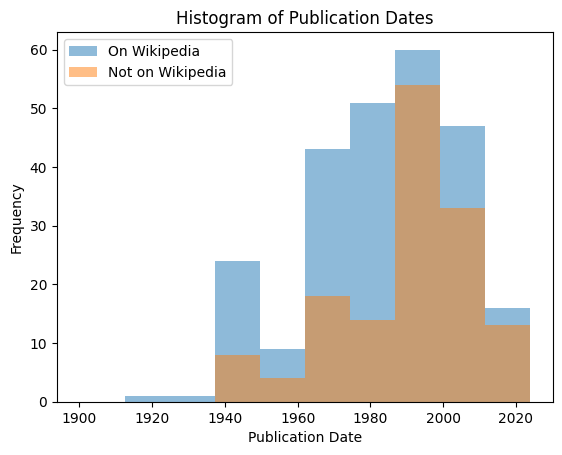

In [1]:
# Look at families where optimal time algo is not on Wikipedia. Scatterplot of publication dates for on Wiki and not on Wiki
import matplotlib.pyplot as plt
import pandas as pd

def optimal_time_not_on_wiki():
    df = pd.read_csv('data/merged.csv')
    df = df[['is_optimal', 'One of them', 'Year']]
    data = df.to_dict(orient='records')
    publication_date_not_on_wiki = []
    publication_date_on_wiki = []
    for algo in data:
        if algo['is_optimal'] == 1:
            if algo['One of them'] == 1:
                publication_date_on_wiki.append(algo['Year'])
            elif algo['One of them'] == 0:
                publication_date_not_on_wiki.append(algo['Year'])
    avg_on_wiki = sum(publication_date_on_wiki)/len(publication_date_on_wiki)
    avg_non_wiki = sum(publication_date_not_on_wiki)/len(publication_date_not_on_wiki)
    print("Average publication date for optimal time algorithms on Wikipedia: " + str(avg_on_wiki))
    print("Average publication date for optimal time algorithms not on Wikipedia: " + str(avg_non_wiki))

    plt.hist(publication_date_on_wiki, bins=10, range=(1900, 2024), alpha=0.5, label='On Wikipedia')
    plt.hist(publication_date_not_on_wiki, bins=10, range=(1900, 2024), alpha=0.5, label='Not on Wikipedia')

    plt.xlabel('Publication Date')
    plt.ylabel('Frequency')
    plt.title('Histogram of Publication Dates')
    plt.legend()
    plt.show()

def main():
    optimal_time_not_on_wiki()

if __name__ == "__main__":
    main()


Average publication date for optimal time algorithms on Wikipedia: 1949.8692307692309
Average publication date for optimal time algorithms not on Wikipedia: 1987.8150684931506


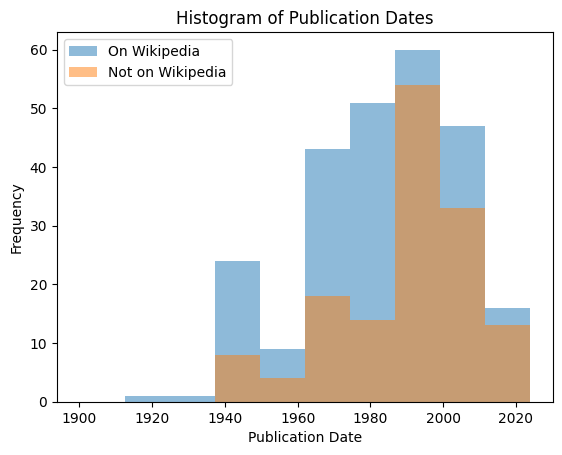

In [2]:
# Look at families where optimal time algo is not on Wikipedia. Scatterplot of publication dates for on Wiki and not on Wiki
import pandas as pd
import matplotlib.pyplot as plt

def optimal_time_not_on_wiki():
    df = pd.read_csv('data/merged.csv')
    df = df[['is_optimal', 'One of them', 'Year']]
    data = df.to_dict(orient='records')
    publication_date_not_on_wiki = []
    publication_date_on_wiki = []
    for algo in data:
        if algo['is_optimal'] == 1:
            if algo['One of them'] == 1:
                publication_date_on_wiki.append(algo['Year'])
            elif algo['One of them'] == 0:
                publication_date_not_on_wiki.append(algo['Year'])
    avg_on_wiki = sum(publication_date_on_wiki)/len(publication_date_on_wiki)
    avg_non_wiki = sum(publication_date_not_on_wiki)/len(publication_date_not_on_wiki)
    print("Average publication date for optimal time algorithms on Wikipedia: " + str(avg_on_wiki))
    print("Average publication date for optimal time algorithms not on Wikipedia: " + str(avg_non_wiki))

    plt.hist(publication_date_on_wiki, bins=10, range=(1900, 2024), alpha=0.5, label='On Wikipedia')
    plt.hist(publication_date_not_on_wiki, bins=10, range=(1900, 2024), alpha=0.5, label='Not on Wikipedia')

    plt.xlabel('Publication Date')
    plt.ylabel('Frequency')
    plt.title('Histogram of Publication Dates')
    plt.legend()
    plt.show()

def main():
    optimal_time_not_on_wiki()

if __name__ == "__main__":
    main()

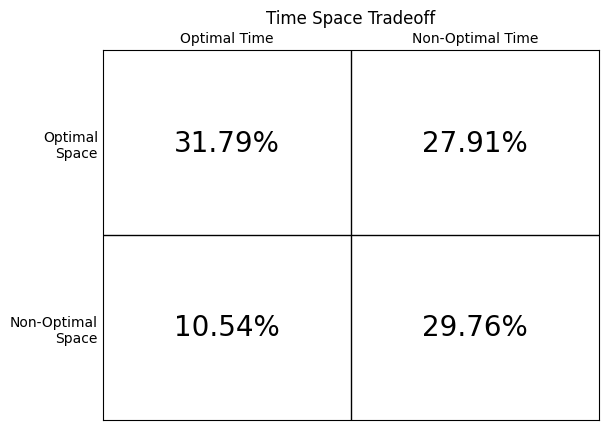

In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

df = pd.read_csv('data/merged1.csv')
df = df[['is_optimal', 'is_optimal_space', 'One of them']]
data = df.to_dict(orient='records')
total = 0
opt_time_space = 0
opt_time = 0
opt_space = 0
none = 0
for algo in data:
    if algo['One of them'] == 1:
        total += 1
        if algo['is_optimal'] and algo['is_optimal_space']:
            opt_time_space += 1
        elif algo['is_optimal'] and not algo['is_optimal_space']: 
            opt_time += 1
        elif not algo['is_optimal'] and algo['is_optimal_space']:
            opt_space += 1
        elif not algo['is_optimal'] and not algo['is_optimal_space']:
            none += 1

opt_time_space = opt_time_space/total
opt_time = opt_time/total
opt_space = opt_space/total
none = none/total

x = np.array([-10, 10, -10, 10])
y = np.array([10,10, -10, -10])
n = [str(round(opt_time_space*100, 2)) + '%', str(round(opt_space*100, 2)) + '%', str(round(opt_time*100, 2)) + '%', str(round(none*100, 2)) + '%']
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.scatter(x, y, alpha=0)
for i, txt in enumerate(n):
    plt.annotate(txt, (x[i], y[i]), ha='center', va='center', fontsize=20)
plt.axhline(y = 0, color = 'black', linestyle = '-', linewidth = 1)
plt.axvline(x = 0, color = 'black', linestyle = '-', linewidth = 1) 
plt.title('Time Space Tradeoff')
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False, length = 0)
plt.xticks([-10, 10], labels=['Optimal Time', 'Non-Optimal Time'])
plt.yticks([-10, 10], labels=['Non-Optimal\nSpace', 'Optimal\nSpace'])

plt.savefig('figures/fig5.png', bbox_inches='tight')
plt.savefig('figures/fig5.pdf', bbox_inches='tight')
plt.show()

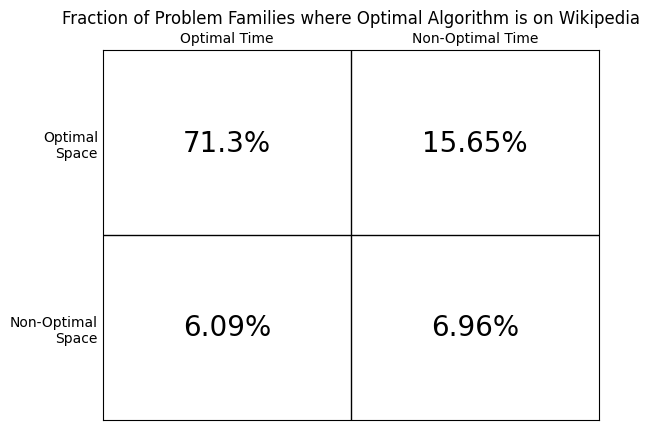

In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

df = pd.read_csv('data/merged1.csv')
df = df[['is_optimal', 'is_optimal_space', 'One of them', 'Family Name']]
data = df.to_dict(orient='records')
families = {}
for algo in data:
    if algo['One of them'] == 1:
        if algo['Family Name'] not in families.keys():
            families[algo['Family Name']] = [algo['is_optimal'], algo['is_optimal_space']]
        else:
            if algo['is_optimal']:
                families[algo['Family Name']][0] = True
            if algo['is_optimal_space']:
                families[algo['Family Name']][1] = True
# print(families)

total = 0
opt_time_space = 0
opt_time = 0
opt_space = 0
none = 0

for key, value in families.items():
    total += 1
    if value[0] and value[1]:
        opt_time_space += 1
    elif value[0]:
        opt_time += 1
    elif value[1]:
        opt_space += 1
    else: 
        none += 1

opt_time_space = opt_time_space/total
opt_time = opt_time/total
opt_space = opt_space/total
none = none/total

x = np.array([-10, 10, -10, 10])
y = np.array([10,10, -10, -10])
n = [str(round(opt_time_space*100, 2)) + '%', str(round(opt_space*100, 2)) + '%', str(round(opt_time*100, 2)) + '%', str(round(none*100, 2)) + '%']
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.scatter(x, y, alpha=0)
for i, txt in enumerate(n):
    plt.annotate(txt, (x[i], y[i]), ha='center', va='center', fontsize=20)
plt.axhline(y = 0, color = 'black', linestyle = '-', linewidth = 1)
plt.axvline(x = 0, color = 'black', linestyle = '-', linewidth = 1) 
plt.title('Fraction of Problem Families where Optimal Algorithm is on Wikipedia')
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False, length = 0)
plt.xticks([-10, 10], labels=['Optimal Time', 'Non-Optimal Time'])
plt.yticks([-10, 10], labels=['Non-Optimal\nSpace', 'Optimal\nSpace'])

plt.show()